## Imports and Setup 

In [299]:
import  pandas as pd
import numpy as np
import json
from pandas import json_normalize
import matplotlib.pyplot as plt
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.ticker as mticker
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import re
from datetime import datetime

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE   = sns.color_palette('muted')
FIG_BG    = '#F8F9FA'
ACCENT    = '#2B6CB0'
plt.rcParams.update({'figure.facecolor': FIG_BG, 'axes.facecolor': FIG_BG,
                     'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

# Primary Data Understanding

In [300]:
MASTER_SCHEMA = [

    # -------------------------
    # 1. Identification
    # -------------------------
    "url",
    "contrat",
    "type",
    "prix",
    "titre",
    "description",

    # -------------------------
    # 3. Price & Physical Features
    # -------------------------
    "surface",
    "pieces",
    "etage",

    # -------------------------
    # 4. Location
    # -------------------------
    "code_postal",
    "adresse",
    "ville",
    "gouvernerat",
    "latitude",
    "longitude",

    # -------------------------
    # 5. Temporal Information
    # -------------------------
    "date_publication",

    # -------------------------
    # 6. Property Quality
    # -------------------------
    "standing",
    "annee_constr",

    # -------------------------
    # 7. Nearby Amenities
    # -------------------------
    "ecole",
    "pharmacie",
    "hopital",
    "marche",
    "magasin",
    "bar",
    "restaurant",
    "transport",
    "caracteristiques",

    # -------------------------
    # 8. Content & Media
    # -------------------------
    "images"
]

## Monbien.tn

In [301]:
data = pd.read_json('datasets/monbien_tn/data.json')
df_monbien = json_normalize(data.to_dict('records'))
df_monbien.info()
df_monbien

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6939 entries, 0 to 6938
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   source                6939 non-null   object
 1   url                   6939 non-null   object
 2   annonce_id            6939 non-null   int64 
 3   transaction           6939 non-null   object
 4   type_bien             6939 non-null   object
 5   titre                 6939 non-null   object
 6   prix                  6939 non-null   object
 7   surface_m2            6939 non-null   object
 8   pieces                6939 non-null   object
 9   chambres              6939 non-null   object
 10  salles_de_bain        6939 non-null   object
 11  localisation          6939 non-null   object
 12  adresse               6939 non-null   object
 13  description           6939 non-null   object
 14  images_csv            6939 non-null   object
 15  caracteristiques_csv  6939 non-null   

,source,url,annonce_id,transaction,type_bien,titre,prix,surface_m2,pieces,chambres,salles_de_bain,localisation,adresse,description,images_csv,caracteristiques_csv,details_csv
0,monbien.tn,https://www.monbien.tn/properties/7599/terrain...,7599,Vente,Terrain,Terrain de 4018 m² à vendre à 200 dt/m² à hamm...,0 DT,4018,,2,,,,Réf: THS063 Nabeul / Hammamet Terrain / à vend...,https://www.monbien.tn/media/cache/resolve/pho...,Terrain de 4018 m² à vendre à 200 dt/m² à hamm...,
1,monbien.tn,https://www.monbien.tn/properties/7592/coquet-...,7592,Vente,Appartement,Coquet studio à vendre à 140 md à hammamet 513...,140 000 DT,,1,2,,,,Réf: AH077 Nabeul / Hammamet Appartement / à v...,https://www.monbien.tn/media/cache/resolve/pho...,Coquet studio à vendre à 140 md à hammamet 513...,
2,monbien.tn,https://www.monbien.tn/properties/7588/villa-t...,7588,Vente,Villa,Villa toute neuve s+3 avec piscine à hammamet ...,650 000 DT,200,3,2,,,,Réf: MHS186 Nabeul / Hammamet Villa / à vendre...,https://www.monbien.tn/media/cache/resolve/pho...,Villa toute neuve s+3 avec piscine à hammamet ...,
3,monbien.tn,https://www.monbien.tn/properties/7596/un-dupl...,7596,Vente,Terrain,Un duplex avec piscine à hammamet nord à vendr...,730 000 DT,220,3,2,,,,Réf: MH112 Nabeul / Hammamet nord Duplex / à v...,https://www.monbien.tn/media/cache/resolve/pho...,Un duplex avec piscine à hammamet nord à vendr...,
4,monbien.tn,https://www.monbien.tn/properties/7594/apparte...,7594,Vente,Appartement,Appartement s+1 avec vue de mer à hammamet à v...,320 000 DT,76,1,2,,,,Réf: AH079 Nabeul / Hammamet centre Appartemen...,https://www.monbien.tn/media/cache/resolve/pho...,Appartement s+1 avec vue de mer à hammamet à v...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6934,monbien.tn,https://www.monbien.tn/properties/7077/bel-app...,7077,Vente,Appartement,Bel appartement s+1 à vendre à afh mrezga 5135...,250 000 DT,90,1,2,,,,Réf: AM091 Nabeul / Mrezga Appartement / à ven...,https://www.monbien.tn/media/cache/resolve/pho...,Bel appartement s+1 à vendre à afh mrezga 5135...,
6935,monbien.tn,https://www.monbien.tn/properties/4831/villa-a...,4831,Location,Villa,"Villa azur à louer à sidi daoud, la marsa",4 200 DT,,,2,,,,Réf: OF91933 Tunis / La marsa Villa / à louer ...,https://www.monbien.tn/media/cache/resolve/pho...,"Villa azur à louer à sidi daoud, la marsa | Vi...",
6936,monbien.tn,https://www.monbien.tn/properties/4840/appart-...,4840,Location,Appartement,Appart s3 rano à louer à cité el ghazela,1 100 DT,,,2,,,,Réf: OF92209 Ariana / Ghazela Appartement / à ...,https://www.monbien.tn/media/cache/resolve/pho...,Appart s3 rano à louer à cité el ghazela | App...,
6937,monbien.tn,https://www.monbien.tn/properties/4848/duplex-...,4848,Location,Duplex,Duplex harmonia à louer à golden tulip,2 900 DT,,,2,,,,Réf: OF92205 Tunis / Gammarth Duplex / à louer...,https://www.monbien.tn/media/cache/resolve/pho...,Duplex harmonia à louer à golden tulip | Duple...,


In [302]:
#remove empty strings and common null indicators
df_monbien = df_monbien.replace(
    ["", " ", "NA", "N/A", "na", "null", "None", None],
    np.nan
)
null_table = (
    pd.DataFrame({
        "Null Count": df_monbien.isna().sum(),
        "Null Percentage (%)": df_monbien.isna().mean() * 100
    })
    .round(2)
    .sort_values(by="Null Percentage (%)", ascending=False)
)

print(null_table)


                      Null Count  Null Percentage (%)
details_csv                 6939               100.00
adresse                     6939               100.00
salles_de_bain              6916                99.67
localisation                6752                97.31
pieces                      3360                48.42
surface_m2                  1992                28.71
type_bien                    259                 3.73
chambres                     250                 3.60
source                         0                 0.00
titre                          0                 0.00
prix                           0                 0.00
annonce_id                     0                 0.00
transaction                    0                 0.00
url                            0                 0.00
description                    0                 0.00
images_csv                     0                 0.00
caracteristiques_csv           0                 0.00


### Data Prep

In [303]:
df_monbien_std = df_monbien.drop(columns=[col for col in df_monbien.columns if df_monbien[col].isna().all()])
df_monbien_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6939 entries, 0 to 6938
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   source                6939 non-null   object
 1   url                   6939 non-null   object
 2   annonce_id            6939 non-null   int64 
 3   transaction           6939 non-null   object
 4   type_bien             6680 non-null   object
 5   titre                 6939 non-null   object
 6   prix                  6939 non-null   object
 7   surface_m2            4947 non-null   object
 8   pieces                3579 non-null   object
 9   chambres              6689 non-null   object
 10  salles_de_bain        23 non-null     object
 11  localisation          187 non-null    object
 12  description           6939 non-null   object
 13  images_csv            6939 non-null   object
 14  caracteristiques_csv  6939 non-null   object
dtypes: int64(1), object(14)
memory usage: 

In [304]:
def normalize_schema(df, mapping):
    # rename columns to master names
    df = df.rename(columns=mapping)

    # add missing columns
    for col in MASTER_SCHEMA:
        if col not in df.columns:
            df[col] = None

    # keep only master schema order
    df = df[MASTER_SCHEMA]

    return df

In [305]:
mapping_monbien = {
    "url": "url",
    "transaction": "contrat",
    "description": "description",
    "titre": "titre",
    "pieces": "pieces",
    "prix": "prix",
    "type_bien": "type",
    "surface_m2": "surface",
    "localisation": "ville",
    "caracteristiques_csv": "caracteristiques",
    "images_csv": "images"
}
df_monbien_std = normalize_schema(df_monbien_std, mapping_monbien)
df_monbien_std.info()
df_monbien_std

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6939 entries, 0 to 6938
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               6939 non-null   object
 1   contrat           6939 non-null   object
 2   type              6680 non-null   object
 3   prix              6939 non-null   object
 4   titre             6939 non-null   object
 5   description       6939 non-null   object
 6   surface           4947 non-null   object
 7   pieces            3579 non-null   object
 8   etage             0 non-null      object
 9   code_postal       0 non-null      object
 10  adresse           0 non-null      object
 11  ville             187 non-null    object
 12  gouvernerat       0 non-null      object
 13  latitude          0 non-null      object
 14  longitude         0 non-null      object
 15  date_publication  0 non-null      object
 16  standing          0 non-null      object
 17  annee_constr  

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.monbien.tn/properties/7599/terrain...,Vente,Terrain,0 DT,Terrain de 4018 m² à vendre à 200 dt/m² à hamm...,Réf: THS063 Nabeul / Hammamet Terrain / à vend...,4018,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Terrain de 4018 m² à vendre à 200 dt/m² à hamm...,https://www.monbien.tn/media/cache/resolve/pho...
1,https://www.monbien.tn/properties/7592/coquet-...,Vente,Appartement,140 000 DT,Coquet studio à vendre à 140 md à hammamet 513...,Réf: AH077 Nabeul / Hammamet Appartement / à v...,NaN,1,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Coquet studio à vendre à 140 md à hammamet 513...,https://www.monbien.tn/media/cache/resolve/pho...
2,https://www.monbien.tn/properties/7588/villa-t...,Vente,Villa,650 000 DT,Villa toute neuve s+3 avec piscine à hammamet ...,Réf: MHS186 Nabeul / Hammamet Villa / à vendre...,200,3,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Villa toute neuve s+3 avec piscine à hammamet ...,https://www.monbien.tn/media/cache/resolve/pho...
3,https://www.monbien.tn/properties/7596/un-dupl...,Vente,Terrain,730 000 DT,Un duplex avec piscine à hammamet nord à vendr...,Réf: MH112 Nabeul / Hammamet nord Duplex / à v...,220,3,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Un duplex avec piscine à hammamet nord à vendr...,https://www.monbien.tn/media/cache/resolve/pho...
4,https://www.monbien.tn/properties/7594/apparte...,Vente,Appartement,320 000 DT,Appartement s+1 avec vue de mer à hammamet à v...,Réf: AH079 Nabeul / Hammamet centre Appartemen...,76,1,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Appartement s+1 avec vue de mer à hammamet à v...,https://www.monbien.tn/media/cache/resolve/pho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6934,https://www.monbien.tn/properties/7077/bel-app...,Vente,Appartement,250 000 DT,Bel appartement s+1 à vendre à afh mrezga 5135...,Réf: AM091 Nabeul / Mrezga Appartement / à ven...,90,1,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Bel appartement s+1 à vendre à afh mrezga 5135...,https://www.monbien.tn/media/cache/resolve/pho...
6935,https://www.monbien.tn/properties/4831/villa-a...,Location,Villa,4 200 DT,"Villa azur à louer à sidi daoud, la marsa",Réf: OF91933 Tunis / La marsa Villa / à louer ...,NaN,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"Villa azur à louer à sidi daoud, la marsa | Vi...",https://www.monbien.tn/media/cache/resolve/pho...
6936,https://www.monbien.tn/properties/4840/appart-...,Location,Appartement,1 100 DT,Appart s3 rano à louer à cité el ghazela,Réf: OF92209 Ariana / Ghazela Appartement / à ...,NaN,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Appart s3 rano à louer à cité el ghazela | App...,https://www.monbien.tn/media/cache/resolve/pho...
6937,https://www.monbien.tn/properties/4848/duplex-...,Location,Duplex,2 900 DT,Duplex harmonia à louer à golden tulip,Réf: OF92205 Tunis / Gammarth Duplex / à louer...,NaN,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Duplex harmonia à louer à golden tulip | Duple...,https://www.monbien.tn/media/cache/resolve/pho...


In [306]:
df_monbien_std["description"] = np.where(
    df_monbien_std["caracteristiques"].notna(),
    df_monbien_std["description"].fillna("") +
    "\nCaracteristiques: " +
    df_monbien_std["caracteristiques"],
    df_monbien_std["description"]
)

df_monbien_std["caracteristiques"] = np.nan
df_monbien_std

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.monbien.tn/properties/7599/terrain...,Vente,Terrain,0 DT,Terrain de 4018 m² à vendre à 200 dt/m² à hamm...,Réf: THS063 Nabeul / Hammamet Terrain / à vend...,4018,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
1,https://www.monbien.tn/properties/7592/coquet-...,Vente,Appartement,140 000 DT,Coquet studio à vendre à 140 md à hammamet 513...,Réf: AH077 Nabeul / Hammamet Appartement / à v...,NaN,1,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
2,https://www.monbien.tn/properties/7588/villa-t...,Vente,Villa,650 000 DT,Villa toute neuve s+3 avec piscine à hammamet ...,Réf: MHS186 Nabeul / Hammamet Villa / à vendre...,200,3,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
3,https://www.monbien.tn/properties/7596/un-dupl...,Vente,Terrain,730 000 DT,Un duplex avec piscine à hammamet nord à vendr...,Réf: MH112 Nabeul / Hammamet nord Duplex / à v...,220,3,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
4,https://www.monbien.tn/properties/7594/apparte...,Vente,Appartement,320 000 DT,Appartement s+1 avec vue de mer à hammamet à v...,Réf: AH079 Nabeul / Hammamet centre Appartemen...,76,1,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6934,https://www.monbien.tn/properties/7077/bel-app...,Vente,Appartement,250 000 DT,Bel appartement s+1 à vendre à afh mrezga 5135...,Réf: AM091 Nabeul / Mrezga Appartement / à ven...,90,1,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
6935,https://www.monbien.tn/properties/4831/villa-a...,Location,Villa,4 200 DT,"Villa azur à louer à sidi daoud, la marsa",Réf: OF91933 Tunis / La marsa Villa / à louer ...,NaN,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
6936,https://www.monbien.tn/properties/4840/appart-...,Location,Appartement,1 100 DT,Appart s3 rano à louer à cité el ghazela,Réf: OF92209 Ariana / Ghazela Appartement / à ...,NaN,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
6937,https://www.monbien.tn/properties/4848/duplex-...,Location,Duplex,2 900 DT,Duplex harmonia à louer à golden tulip,Réf: OF92205 Tunis / Gammarth Duplex / à louer...,NaN,NaN,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...


#### Data type conversion

In [307]:
df_monbien_std["prix"] = (
    df_monbien_std["prix"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # keep only numbers
)

df_monbien_std["prix"] = pd.to_numeric(df_monbien_std["prix"], errors="coerce")

df_monbien_std["surface"] = pd.to_numeric(df_monbien_std["surface"], errors="coerce")

df_monbien_std["etage"] = pd.to_numeric(df_monbien_std["etage"], errors="coerce")
df_monbien_std["annee_constr"] = pd.to_numeric(df_monbien_std["annee_constr"], errors="coerce")

df_monbien_std["pieces"] = pd.to_numeric(df_monbien_std["pieces"], errors="coerce")
df_monbien_std["pieces"] += 1

df_monbien_std["date_publication"] = pd.to_datetime(df_monbien_std["date_publication"], errors="coerce")

df_monbien_std


,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.monbien.tn/properties/7599/terrain...,Vente,Terrain,0,Terrain de 4018 m² à vendre à 200 dt/m² à hamm...,Réf: THS063 Nabeul / Hammamet Terrain / à vend...,4018.00,NaN,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
1,https://www.monbien.tn/properties/7592/coquet-...,Vente,Appartement,140000,Coquet studio à vendre à 140 md à hammamet 513...,Réf: AH077 Nabeul / Hammamet Appartement / à v...,NaN,2.00,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
2,https://www.monbien.tn/properties/7588/villa-t...,Vente,Villa,650000,Villa toute neuve s+3 avec piscine à hammamet ...,Réf: MHS186 Nabeul / Hammamet Villa / à vendre...,200.00,4.00,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
3,https://www.monbien.tn/properties/7596/un-dupl...,Vente,Terrain,730000,Un duplex avec piscine à hammamet nord à vendr...,Réf: MH112 Nabeul / Hammamet nord Duplex / à v...,220.00,4.00,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
4,https://www.monbien.tn/properties/7594/apparte...,Vente,Appartement,320000,Appartement s+1 avec vue de mer à hammamet à v...,Réf: AH079 Nabeul / Hammamet centre Appartemen...,76.00,2.00,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6934,https://www.monbien.tn/properties/7077/bel-app...,Vente,Appartement,250000,Bel appartement s+1 à vendre à afh mrezga 5135...,Réf: AM091 Nabeul / Mrezga Appartement / à ven...,90.00,2.00,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
6935,https://www.monbien.tn/properties/4831/villa-a...,Location,Villa,4200,"Villa azur à louer à sidi daoud, la marsa",Réf: OF91933 Tunis / La marsa Villa / à louer ...,NaN,NaN,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
6936,https://www.monbien.tn/properties/4840/appart-...,Location,Appartement,1100,Appart s3 rano à louer à cité el ghazela,Réf: OF92209 Ariana / Ghazela Appartement / à ...,NaN,NaN,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...
6937,https://www.monbien.tn/properties/4848/duplex-...,Location,Duplex,2900,Duplex harmonia à louer à golden tulip,Réf: OF92205 Tunis / Gammarth Duplex / à louer...,NaN,NaN,NaN,None,None,NaN,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,https://www.monbien.tn/media/cache/resolve/pho...


## Immobilier.tn

In [308]:
data = pd.read_json('datasets/immobilier_com_tn/data.json')
df_immobilier_tn = json_normalize(data.to_dict('records'))
df_immobilier_tn.info()
df_immobilier_tn

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   source                896 non-null    object
 1   url                   896 non-null    object
 2   annonce_id            896 non-null    int64 
 3   transaction           896 non-null    object
 4   type_bien             896 non-null    object
 5   titre                 896 non-null    object
 6   prix                  896 non-null    object
 7   surface_m2            896 non-null    object
 8   pieces                896 non-null    object
 9   chambres              896 non-null    object
 10  salles_de_bain        896 non-null    object
 11  localisation          896 non-null    object
 12  adresse               896 non-null    object
 13  description           896 non-null    object
 14  images_csv            896 non-null    object
 15  caracteristiques_csv  896 non-null    ob

,source,url,annonce_id,transaction,type_bien,titre,prix,surface_m2,pieces,chambres,salles_de_bain,localisation,adresse,description,images_csv,caracteristiques_csv,details_csv
0,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33625/lo...,33625,Location,Bureau,Location : Local bureautique à louer (Marsa Ma...,2 300 DT,148,,,,Tunis,rue }; Bureau 148 m² 4 Nous vous proposons à l...,Local bureautique à louer (Marsa Mall) Sidi Da...,,Bureau | 148 m² | Étage 1er étage | Climatisat...,
1,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33645/a-...,33645,Location,Appartement,Location : A louer Etage de villa à Jardin d’E...,1 850 DT,180,3,,,Ariana,rue }; Appartement 180 m² 3 À louer – Étage de...,A louer Etage de villa à Jardin d’El menzah 2 ...,,Appartement | 180 m² | Chauffage Central | Éta...,
2,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33502/al...,33502,Location,Bureau,Location : AL Bureau 346m² au Lac1 - immobilie...,10 700 DT,346,,,,Tunis - Lac1,"Bloc B, 4ème étage, Immeuble Constance, Rue du...","Bloc B, 4ème étage, Immeuble Constance, Rue du...",,Bureau | 346 m²,
3,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33651/bu...,33651,Location,Appartement,Location : bureau haut standing - Pacha centre...,,90,,,,Tunis,rue }; Appartement 90 m² 3 A louer un bureau h...,bureau haut standing - Pacha centre Pacha cent...,,Appartement | 90 m² | Parking | Alarme | Ascen...,
4,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33619/s1...,33619,Location,Appartement,Location : S+1 à louer - La Marsa (cité el Kha...,1 000 DT,43,1,,,Tunis,rue }; Appartement 43 m² Studio Cet appartemen...,S+1 à louer - La Marsa (cité el Khalil) Cite E...,,Appartement | 43 m² | Studio | Chauffage Gaz |...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33637/ap...,33637,Location,Appartement,Location : appartement deux chambres - immobi...,650 DT,82,2,,,Ariana,rue }; Appartement 82 m² 2 Appartement propre ...,"appartement deux chambres Cite Ennour Jaafar, ...",,Appartement | 82 m² | Chauffage | Étage | Park...,
892,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33503/al...,33503,Location,Bureau,Location : AL Bureau au lac3 - immobilier.com.tn,8 200 DT,492,,,,Tunis,"Bloc B, 4ème étage, Immeuble Constance, Rue du...","Bloc B, 4ème étage, Immeuble Constance, Rue du...",,Bureau | 492 m²,
893,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33624/au...,33624,Location,Appartement,Location : Au coeur de la Marsa - immobilier....,4 200 DT,80,2,,,Tunis,"rue }; Appartement 80 m² 2 À louer à la Marsa,...","Au coeur de la Marsa Marsa Safsaf, La Marsa, T...",,Appartement | 80 m² | Meublé | Chauffage | Rez...,
894,immobilier.com.tn,https://www.immobilier.com.tn/annonce/33648/a-...,33648,Location,Villa,Location : A louer duplex résidence Riadh Borj...,,124,,,,Ariana,rue }; Villa 124 m² 4 À louer – Duplex à Résid...,A louer duplex résidence Riadh Borj touil Raou...,,Villa | 124 m²,


In [309]:
df_immobilier_tn = df_immobilier_tn.replace(
    ["", " ", "NA", "N/A", "na", "null", "None", None],
    np.nan
)
null_table = (
    pd.DataFrame({
        "Null Count": df_immobilier_tn.isna().sum(),
        "Null Percentage (%)": df_immobilier_tn.isna().mean() * 100
    })
    .round(2)
    .sort_values(by="Null Percentage (%)", ascending=False)
)

print(null_table)

                      Null Count  Null Percentage (%)
salles_de_bain               896               100.00
chambres                     896               100.00
details_csv                  896               100.00
localisation                 458                51.12
pieces                       342                38.17
surface_m2                   179                19.98
adresse                       92                10.27
images_csv                    31                 3.46
prix                          15                 1.67
transaction                    2                 0.22
type_bien                      1                 0.11
source                         0                 0.00
annonce_id                     0                 0.00
titre                          0                 0.00
url                            0                 0.00
description                    0                 0.00
caracteristiques_csv           0                 0.00


### Data Prep

In [310]:
df_immobilier_tn_std = df_immobilier_tn.drop(columns=[col for col in df_immobilier_tn.columns if df_immobilier_tn[col].isna().all()])
df_immobilier_tn_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   source                896 non-null    object
 1   url                   896 non-null    object
 2   annonce_id            896 non-null    int64 
 3   transaction           894 non-null    object
 4   type_bien             895 non-null    object
 5   titre                 896 non-null    object
 6   prix                  881 non-null    object
 7   surface_m2            717 non-null    object
 8   pieces                554 non-null    object
 9   localisation          438 non-null    object
 10  adresse               804 non-null    object
 11  description           896 non-null    object
 12  images_csv            865 non-null    object
 13  caracteristiques_csv  896 non-null    object
dtypes: int64(1), object(13)
memory usage: 98.1+ KB


In [311]:
def normalize_schema(df, mapping):
    # rename columns to master names
    df = df.rename(columns=mapping)

    # add missing columns
    for col in MASTER_SCHEMA:
        if col not in df.columns:
            df[col] = None

    # keep only master schema order
    df = df[MASTER_SCHEMA]

    return df

In [312]:
mapping_immobilier_tn = {
    "url": "url",
    "transaction": "contrat",
    "description": "description",
    "titre": "titre",
    "pieces": "pieces",
    "prix": "prix",
    "adresse": "adresse",
    "type_bien": "type",
    "surface_m2": "surface",
    "localisation": "ville",
    "caracteristiques_csv": "caracteristiques",
    "images_csv": "images"
}
df_immobilier_tn_std = normalize_schema(df_immobilier_tn_std, mapping_immobilier_tn)
df_immobilier_tn_std.info()
df_immobilier_tn_std

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 896 entries, 0 to 895
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               896 non-null    object
 1   contrat           894 non-null    object
 2   type              895 non-null    object
 3   prix              881 non-null    object
 4   titre             896 non-null    object
 5   description       896 non-null    object
 6   surface           717 non-null    object
 7   pieces            554 non-null    object
 8   etage             0 non-null      object
 9   code_postal       0 non-null      object
 10  adresse           804 non-null    object
 11  ville             438 non-null    object
 12  gouvernerat       0 non-null      object
 13  latitude          0 non-null      object
 14  longitude         0 non-null      object
 15  date_publication  0 non-null      object
 16  standing          0 non-null      object
 17  annee_constr    

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.immobilier.com.tn/annonce/33625/lo...,Location,Bureau,2 300 DT,Location : Local bureautique à louer (Marsa Ma...,Local bureautique à louer (Marsa Mall) Sidi Da...,148,NaN,None,None,rue }; Bureau 148 m² 4 Nous vous proposons à l...,Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Bureau | 148 m² | Étage 1er étage | Climatisat...,NaN
1,https://www.immobilier.com.tn/annonce/33645/a-...,Location,Appartement,1 850 DT,Location : A louer Etage de villa à Jardin d’E...,A louer Etage de villa à Jardin d’El menzah 2 ...,180,3,None,None,rue }; Appartement 180 m² 3 À louer – Étage de...,Ariana,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Appartement | 180 m² | Chauffage Central | Éta...,NaN
2,https://www.immobilier.com.tn/annonce/33502/al...,Location,Bureau,10 700 DT,Location : AL Bureau 346m² au Lac1 - immobilie...,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",346,NaN,None,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis - Lac1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Bureau | 346 m²,NaN
3,https://www.immobilier.com.tn/annonce/33651/bu...,Location,Appartement,NaN,Location : bureau haut standing - Pacha centre...,bureau haut standing - Pacha centre Pacha cent...,90,NaN,None,None,rue }; Appartement 90 m² 3 A louer un bureau h...,Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Appartement | 90 m² | Parking | Alarme | Ascen...,NaN
4,https://www.immobilier.com.tn/annonce/33619/s1...,Location,Appartement,1 000 DT,Location : S+1 à louer - La Marsa (cité el Kha...,S+1 à louer - La Marsa (cité el Khalil) Cite E...,43,1,None,None,rue }; Appartement 43 m² Studio Cet appartemen...,Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Appartement | 43 m² | Studio | Chauffage Gaz |...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,https://www.immobilier.com.tn/annonce/33637/ap...,Location,Appartement,650 DT,Location : appartement deux chambres - immobi...,"appartement deux chambres Cite Ennour Jaafar, ...",82,2,None,None,rue }; Appartement 82 m² 2 Appartement propre ...,Ariana,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Appartement | 82 m² | Chauffage | Étage | Park...,NaN
892,https://www.immobilier.com.tn/annonce/33503/al...,Location,Bureau,8 200 DT,Location : AL Bureau au lac3 - immobilier.com.tn,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",492,NaN,None,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Bureau | 492 m²,NaN
893,https://www.immobilier.com.tn/annonce/33624/au...,Location,Appartement,4 200 DT,Location : Au coeur de la Marsa - immobilier....,"Au coeur de la Marsa Marsa Safsaf, La Marsa, T...",80,2,None,None,"rue }; Appartement 80 m² 2 À louer à la Marsa,...",Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Appartement | 80 m² | Meublé | Chauffage | Rez...,NaN
894,https://www.immobilier.com.tn/annonce/33648/a-...,Location,Villa,NaN,Location : A louer duplex résidence Riadh Borj...,A louer duplex résidence Riadh Borj touil Raou...,124,NaN,None,None,rue }; Villa 124 m² 4 À louer – Duplex à Résid...,Ariana,None,None,None,None,None,None,None,None,None,None,None,None,None,None,Villa | 124 m²,NaN


In [313]:
df_immobilier_tn_std["description"] = np.where(
    df_immobilier_tn_std["caracteristiques"].notna(),
    df_immobilier_tn_std["description"].fillna("") +
    "\nCaracteristiques: " +
    df_immobilier_tn_std["caracteristiques"],
    df_immobilier_tn_std["description"]
)

df_immobilier_tn_std["caracteristiques"] = np.nan
df_immobilier_tn_std

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.immobilier.com.tn/annonce/33625/lo...,Location,Bureau,2 300 DT,Location : Local bureautique à louer (Marsa Ma...,Local bureautique à louer (Marsa Mall) Sidi Da...,148,NaN,None,None,rue }; Bureau 148 m² 4 Nous vous proposons à l...,Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
1,https://www.immobilier.com.tn/annonce/33645/a-...,Location,Appartement,1 850 DT,Location : A louer Etage de villa à Jardin d’E...,A louer Etage de villa à Jardin d’El menzah 2 ...,180,3,None,None,rue }; Appartement 180 m² 3 À louer – Étage de...,Ariana,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
2,https://www.immobilier.com.tn/annonce/33502/al...,Location,Bureau,10 700 DT,Location : AL Bureau 346m² au Lac1 - immobilie...,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",346,NaN,None,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis - Lac1,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
3,https://www.immobilier.com.tn/annonce/33651/bu...,Location,Appartement,NaN,Location : bureau haut standing - Pacha centre...,bureau haut standing - Pacha centre Pacha cent...,90,NaN,None,None,rue }; Appartement 90 m² 3 A louer un bureau h...,Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
4,https://www.immobilier.com.tn/annonce/33619/s1...,Location,Appartement,1 000 DT,Location : S+1 à louer - La Marsa (cité el Kha...,S+1 à louer - La Marsa (cité el Khalil) Cite E...,43,1,None,None,rue }; Appartement 43 m² Studio Cet appartemen...,Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,https://www.immobilier.com.tn/annonce/33637/ap...,Location,Appartement,650 DT,Location : appartement deux chambres - immobi...,"appartement deux chambres Cite Ennour Jaafar, ...",82,2,None,None,rue }; Appartement 82 m² 2 Appartement propre ...,Ariana,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
892,https://www.immobilier.com.tn/annonce/33503/al...,Location,Bureau,8 200 DT,Location : AL Bureau au lac3 - immobilier.com.tn,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",492,NaN,None,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
893,https://www.immobilier.com.tn/annonce/33624/au...,Location,Appartement,4 200 DT,Location : Au coeur de la Marsa - immobilier....,"Au coeur de la Marsa Marsa Safsaf, La Marsa, T...",80,2,None,None,"rue }; Appartement 80 m² 2 À louer à la Marsa,...",Tunis,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN
894,https://www.immobilier.com.tn/annonce/33648/a-...,Location,Villa,NaN,Location : A louer duplex résidence Riadh Borj...,A louer duplex résidence Riadh Borj touil Raou...,124,NaN,None,None,rue }; Villa 124 m² 4 À louer – Duplex à Résid...,Ariana,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN


#### Data type conversion

In [314]:
df_immobilier_tn_std["prix"] = (
    df_immobilier_tn_std["prix"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # keep only numbers
)

df_immobilier_tn_std["prix"] = pd.to_numeric(df_immobilier_tn_std["prix"], errors="coerce")

df_immobilier_tn_std["surface"] = pd.to_numeric(df_immobilier_tn_std["surface"], errors="coerce")

df_immobilier_tn_std["etage"] = pd.to_numeric(df_immobilier_tn_std["etage"], errors="coerce")
df_immobilier_tn_std["annee_constr"] = pd.to_numeric(df_immobilier_tn_std["annee_constr"], errors="coerce")

df_immobilier_tn_std["pieces"] = pd.to_numeric(df_immobilier_tn_std["pieces"], errors="coerce")
df_immobilier_tn_std["pieces"] += 1

df_immobilier_tn_std["date_publication"] = pd.to_datetime(df_immobilier_tn_std["date_publication"], errors="coerce")

df_immobilier_tn_std


,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.immobilier.com.tn/annonce/33625/lo...,Location,Bureau,2300.00,Location : Local bureautique à louer (Marsa Ma...,Local bureautique à louer (Marsa Mall) Sidi Da...,148.00,NaN,NaN,None,rue }; Bureau 148 m² 4 Nous vous proposons à l...,Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
1,https://www.immobilier.com.tn/annonce/33645/a-...,Location,Appartement,1850.00,Location : A louer Etage de villa à Jardin d’E...,A louer Etage de villa à Jardin d’El menzah 2 ...,180.00,4.00,NaN,None,rue }; Appartement 180 m² 3 À louer – Étage de...,Ariana,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
2,https://www.immobilier.com.tn/annonce/33502/al...,Location,Bureau,10700.00,Location : AL Bureau 346m² au Lac1 - immobilie...,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",346.00,NaN,NaN,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis - Lac1,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
3,https://www.immobilier.com.tn/annonce/33651/bu...,Location,Appartement,NaN,Location : bureau haut standing - Pacha centre...,bureau haut standing - Pacha centre Pacha cent...,90.00,NaN,NaN,None,rue }; Appartement 90 m² 3 A louer un bureau h...,Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
4,https://www.immobilier.com.tn/annonce/33619/s1...,Location,Appartement,1000.00,Location : S+1 à louer - La Marsa (cité el Kha...,S+1 à louer - La Marsa (cité el Khalil) Cite E...,43.00,2.00,NaN,None,rue }; Appartement 43 m² Studio Cet appartemen...,Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,https://www.immobilier.com.tn/annonce/33637/ap...,Location,Appartement,650.00,Location : appartement deux chambres - immobi...,"appartement deux chambres Cite Ennour Jaafar, ...",82.00,3.00,NaN,None,rue }; Appartement 82 m² 2 Appartement propre ...,Ariana,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
892,https://www.immobilier.com.tn/annonce/33503/al...,Location,Bureau,8200.00,Location : AL Bureau au lac3 - immobilier.com.tn,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",492.00,NaN,NaN,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
893,https://www.immobilier.com.tn/annonce/33624/au...,Location,Appartement,4200.00,Location : Au coeur de la Marsa - immobilier....,"Au coeur de la Marsa Marsa Safsaf, La Marsa, T...",80.00,3.00,NaN,None,"rue }; Appartement 80 m² 2 À louer à la Marsa,...",Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
894,https://www.immobilier.com.tn/annonce/33648/a-...,Location,Villa,NaN,Location : A louer duplex résidence Riadh Borj...,A louer duplex résidence Riadh Borj touil Raou...,124.00,NaN,NaN,None,rue }; Villa 124 m² 4 À louer – Duplex à Résid...,Ariana,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN


## Annonces Immobilieres

In [315]:
data = pd.read_json('datasets/annonces_immobilieres/data.json')
df_annonces_immo = json_normalize(data.to_dict('records'))
df_annonces_immo.info()
df_annonces_immo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   source                89 non-null     object 
 1   url                   89 non-null     object 
 2   annonce_id            89 non-null     int64  
 3   transaction           89 non-null     object 
 4   type_bien             0 non-null      float64
 5   titre                 89 non-null     object 
 6   prix                  0 non-null      float64
 7   surface_m2            0 non-null      float64
 8   pieces                0 non-null      float64
 9   chambres              0 non-null      float64
 10  salles_de_bain        0 non-null      float64
 11  localisation          89 non-null     object 
 12  adresse               0 non-null      float64
 13  description           89 non-null     object 
 14  images_csv            89 non-null     object 
 15  caracteristiques_csv  89 

,source,url,annonce_id,transaction,type_bien,titre,prix,surface_m2,pieces,chambres,salles_de_bain,localisation,adresse,description,images_csv,caracteristiques_csv,details_csv
0,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,247,location,NaN,Opportunité Rare Ariana Essoughra. Bâtiment: V...,NaN,NaN,NaN,NaN,NaN,"Ariana, Raoued",NaN,À vendre : un bâtiment habitation commercial i...,https://annonces-immobilieres.tn/images/icon/h...,"Parking pour:2 voitures,Étages ::5 Appartement...","Jardin,Ascenseur,Cuisine équipée,À vendre : un..."
1,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,248,location,NaN,Location Annuelle Appartement en Zone Touristi...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba - Midoun",NaN,Location annuelle d'un appartement en 1er étag...,https://annonces-immobilieres.tn/images/icon/h...,Location annuelle d'un appartement en:1er étag...,"Piscine,Cuisine équipée,Chauffage central,Loca..."
2,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,249,location,NaN,Location Annuelle Villa Neuve à la Zone Touris...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba-Houmt Souk",NaN,Proche de toutes les commodités: Commerces & p...,https://annonces-immobilieres.tn/images/icon/h...,Elle se compose en RDC d'un espace de vie lumi...,"Jardin,Ascenseur,Cuisine équipée,Proche de tou..."
3,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,250,location,NaN,Location Annuelle de Grande Villa à Arkou Djer...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba - Midoun",NaN,Une grande villa à louer à Arkou - Dans un cad...,https://annonces-immobilieres.tn/images/icon/h...,La villa se compose en RDC d'un espace de vie ...,"Garage,Jardin,Ascenseur,Cuisine équipée,Chauff..."
4,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,251,location,NaN,Location Annuelle Sans Meubles - Villa à Ghize...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba-Houmt Souk",NaN,A louer à l'année - une villa neuve de style d...,https://annonces-immobilieres.tn/images/icon/h...,A louer à l'année - une villa neuve de style d...,"Jardin,Ascenseur,Cuisine équipée,A louer à l'a..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,255,location,NaN,Location Annuelle Villa avec Piscine à Houmt S...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba-Houmt Souk",NaN,A louer pour longue durée une villa qui se car...,https://annonces-immobilieres.tn/images/icon/h...,Elle se compose en rez-de-chaussée d'un grand ...,"Garage,Jardin,Ascenseur,Cuisine équipée,Chauff..."
85,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,254,location,NaN,Maison en Rez de Chaussée à Louer à Midoun Dje...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba - Midoun",NaN,A louer pour langue durée une maison meublée à...,https://annonces-immobilieres.tn/images/icon/h...,Une maison en rez de chaussée avec une entrée ...,"Ascenseur,Cuisine équipée,Chauffage central,A ..."
86,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,253,location,NaN,Location Annuelle D'un étage de Villa à la Zon...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba-Houmt Souk",NaN,A louer un grand étage de villa avec accès pis...,https://annonces-immobilieres.tn/images/icon/h...,"L'étage se compose de:2 suites avec dressing, ...","Garage,Cuisine équipée,Chauffage central,A lou..."
87,annonces-immobilieres.tn,https://annonces-immobilieres.tn/annonce/detai...,246,location,NaN,Location Annuelle D'une Villa avec Piscine à S...,NaN,NaN,NaN,NaN,NaN,"Medenine, Djerba-Houmt Souk",NaN,Dans un cadre calme et de proximité de la plag...,https://annonces-immobilieres.tn/images/icon/h...,La villa se compose d'un beau espace de vie : ...,"Garage,Jardin,Ascenseur,Cuisine équipée,Chauff..."


In [316]:
df_annonces_immo = df_annonces_immo.replace(
    ["", " ", "NA", "N/A", "na", "null", "None", None],
    np.nan
)
null_table = (
    pd.DataFrame({
        "Null Count": df_annonces_immo.isna().sum(),
        "Null Percentage (%)": df_annonces_immo.isna().mean() * 100
    })
    .round(2)
    .sort_values(by="Null Percentage (%)", ascending=False)
)

print(null_table)

                      Null Count  Null Percentage (%)
type_bien                     89               100.00
salles_de_bain                89               100.00
pieces                        89               100.00
surface_m2                    89               100.00
prix                          89               100.00
chambres                      89               100.00
adresse                       89               100.00
details_csv                   30                33.71
source                         0                 0.00
titre                          0                 0.00
url                            0                 0.00
annonce_id                     0                 0.00
transaction                    0                 0.00
localisation                   0                 0.00
description                    0                 0.00
images_csv                     0                 0.00
caracteristiques_csv           0                 0.00


### Data Prep

In [317]:
df_annonces_immo_std = df_annonces_immo.drop(columns=[col for col in df_annonces_immo.columns if df_annonces_immo[col].isna().all()])
df_annonces_immo_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   source                89 non-null     object
 1   url                   89 non-null     object
 2   annonce_id            89 non-null     int64 
 3   transaction           89 non-null     object
 4   titre                 89 non-null     object
 5   localisation          89 non-null     object
 6   description           89 non-null     object
 7   images_csv            89 non-null     object
 8   caracteristiques_csv  89 non-null     object
 9   details_csv           59 non-null     object
dtypes: int64(1), object(9)
memory usage: 7.1+ KB


In [318]:
def normalize_schema(df, mapping):
    # rename columns to master names
    df = df.rename(columns=mapping)

    # add missing columns
    for col in MASTER_SCHEMA:
        if col not in df.columns:
            df[col] = None

    # keep only master schema order
    df = df[MASTER_SCHEMA]

    return df

In [319]:
df_annonces_immo_std["caracteristiques_csv"]+= "\n details : " + df_annonces_immo_std["details_csv"]

print (df_annonces_immo_std["caracteristiques_csv"][0])
print ("==================================================")
print (df_annonces_immo_std["details_csv"][0])


Parking pour:2 voitures,Étages ::5 Appartements Déjà Construits – Finitions à Personnaliser,(plomberie à:50%, revêtement et peinture, y compris les escaliers),Répartition sur:3 niveaux :,Bâche à eau:3x6m pour collecter les eaux pluviales,Ariana Essoughra.:12 rue,Membre depuis:2026,Minimum:20% du prix (50,000 TND),Lun-Ven::9h-18h,©:2024 Annonces-Immobilières.tn | Rabaii Group . Tous droits réservés. Créé par
 details : Jardin,Ascenseur,Cuisine équipée,À vendre : un bâtiment habitation commercial implanté dans un quartier chic, calme, entièrement viabilisé et très recherché, à proximité immédiate d’Ariana Essoughra.,Un bien idéal pour investisseurs ou pour un projet familial haut standing, bénéficiant d’un titre foncier individuel (bleu), offrant une parfaite sécurité juridique et une excellente valeur patrimoniale.,Rez-de-chaussée : Villa Haut Standing – Totalement Achevée,Salon spacieux et lumineux,3 chambres confortables,3 salles d’eau modernes,Cuisine équipée haut de gamme,Parking po

In [320]:

mapping_annonces_immo = {
    "url": "url",
    "transaction": "contrat",
    "description": "description",
    "titre": "titre",
    "pieces": "pieces",
    "prix": "prix",
    "adresse": "adresse",
    "type_bien": "type",
    "surface_m2": "surface",
    "localisation": "ville",
    "caracteristiques_csv": "caracteristiques",
    "images_csv": "images"
}
df_annonces_immo_std = normalize_schema(df_annonces_immo_std, mapping_annonces_immo)
df_annonces_immo_std.info()
df_annonces_immo_std

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89 entries, 0 to 88
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   url               89 non-null     object
 1   contrat           89 non-null     object
 2   type              0 non-null      object
 3   prix              0 non-null      object
 4   titre             89 non-null     object
 5   description       89 non-null     object
 6   surface           0 non-null      object
 7   pieces            0 non-null      object
 8   etage             0 non-null      object
 9   code_postal       0 non-null      object
 10  adresse           0 non-null      object
 11  ville             89 non-null     object
 12  gouvernerat       0 non-null      object
 13  latitude          0 non-null      object
 14  longitude         0 non-null      object
 15  date_publication  0 non-null      object
 16  standing          0 non-null      object
 17  annee_constr      

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Opportunité Rare Ariana Essoughra. Bâtiment: V...,À vendre : un bâtiment habitation commercial i...,None,None,None,None,None,"Ariana, Raoued",None,None,None,None,None,None,None,None,None,None,None,None,None,None,"Parking pour:2 voitures,Étages ::5 Appartement...",https://annonces-immobilieres.tn/images/icon/h...
1,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Appartement en Zone Touristi...,Location annuelle d'un appartement en 1er étag...,None,None,None,None,None,"Medenine, Djerba - Midoun",None,None,None,None,None,None,None,None,None,None,None,None,None,None,Location annuelle d'un appartement en:1er étag...,https://annonces-immobilieres.tn/images/icon/h...
2,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Villa Neuve à la Zone Touris...,Proche de toutes les commodités: Commerces & p...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,Elle se compose en RDC d'un espace de vie lumi...,https://annonces-immobilieres.tn/images/icon/h...
3,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle de Grande Villa à Arkou Djer...,Une grande villa à louer à Arkou - Dans un cad...,None,None,None,None,None,"Medenine, Djerba - Midoun",None,None,None,None,None,None,None,None,None,None,None,None,None,None,La villa se compose en RDC d'un espace de vie ...,https://annonces-immobilieres.tn/images/icon/h...
4,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Sans Meubles - Villa à Ghize...,A louer à l'année - une villa neuve de style d...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,A louer à l'année - une villa neuve de style d...,https://annonces-immobilieres.tn/images/icon/h...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Villa avec Piscine à Houmt S...,A louer pour longue durée une villa qui se car...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,Elle se compose en rez-de-chaussée d'un grand ...,https://annonces-immobilieres.tn/images/icon/h...
85,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Maison en Rez de Chaussée à Louer à Midoun Dje...,A louer pour langue durée une maison meublée à...,None,None,None,None,None,"Medenine, Djerba - Midoun",None,None,None,None,None,None,None,None,None,None,None,None,None,None,Une maison en rez de chaussée avec une entrée ...,https://annonces-immobilieres.tn/images/icon/h...
86,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle D'un étage de Villa à la Zon...,A louer un grand étage de villa avec accès pis...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,"L'étage se compose de:2 suites avec dressing, ...",https://annonces-immobilieres.tn/images/icon/h...
87,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle D'une Villa avec Piscine à S...,Dans un cadre calme et de proximité de la plag...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,La villa se compose d'un beau espace de vie : ...,https://annonces-immobilieres.tn/images/icon/h...


In [321]:
df_annonces_immo_std["description"] = np.where(
    df_annonces_immo_std["caracteristiques"].notna(),
    df_annonces_immo_std["description"].fillna("") +
    "\nCaracteristiques: " +
    df_annonces_immo_std["caracteristiques"],
    df_annonces_immo_std["description"]
)

df_annonces_immo_std["caracteristiques"] = np.nan
df_annonces_immo_std

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Opportunité Rare Ariana Essoughra. Bâtiment: V...,À vendre : un bâtiment habitation commercial i...,None,None,None,None,None,"Ariana, Raoued",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
1,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Appartement en Zone Touristi...,Location annuelle d'un appartement en 1er étag...,None,None,None,None,None,"Medenine, Djerba - Midoun",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
2,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Villa Neuve à la Zone Touris...,Proche de toutes les commodités: Commerces & p...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
3,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle de Grande Villa à Arkou Djer...,Une grande villa à louer à Arkou - Dans un cad...,None,None,None,None,None,"Medenine, Djerba - Midoun",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
4,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Sans Meubles - Villa à Ghize...,A louer à l'année - une villa neuve de style d...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle Villa avec Piscine à Houmt S...,A louer pour longue durée une villa qui se car...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
85,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Maison en Rez de Chaussée à Louer à Midoun Dje...,A louer pour langue durée une maison meublée à...,None,None,None,None,None,"Medenine, Djerba - Midoun",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
86,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle D'un étage de Villa à la Zon...,A louer un grand étage de villa avec accès pis...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...
87,https://annonces-immobilieres.tn/annonce/detai...,location,None,None,Location Annuelle D'une Villa avec Piscine à S...,Dans un cadre calme et de proximité de la plag...,None,None,None,None,None,"Medenine, Djerba-Houmt Souk",None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,https://annonces-immobilieres.tn/images/icon/h...


#### Data type conversion

In [322]:
df_annonces_immo_std["prix"] = (
    df_annonces_immo_std["prix"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # keep only numbers
)

df_annonces_immo_std["prix"] = pd.to_numeric(df_annonces_immo_std["prix"], errors="coerce")

df_annonces_immo_std["surface"] = pd.to_numeric(df_annonces_immo_std["surface"], errors="coerce")

df_annonces_immo_std["etage"] = pd.to_numeric(df_annonces_immo_std["etage"], errors="coerce")
df_annonces_immo_std["annee_constr"] = pd.to_numeric(df_annonces_immo_std["annee_constr"], errors="coerce")

df_immobilier_tn_std["pieces"] = pd.to_numeric(df_immobilier_tn_std["pieces"], errors="coerce")

df_immobilier_tn_std["date_publication"] = pd.to_datetime(df_immobilier_tn_std["date_publication"], errors="coerce")

df_immobilier_tn_std


,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.immobilier.com.tn/annonce/33625/lo...,Location,Bureau,2300.00,Location : Local bureautique à louer (Marsa Ma...,Local bureautique à louer (Marsa Mall) Sidi Da...,148.00,NaN,NaN,None,rue }; Bureau 148 m² 4 Nous vous proposons à l...,Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
1,https://www.immobilier.com.tn/annonce/33645/a-...,Location,Appartement,1850.00,Location : A louer Etage de villa à Jardin d’E...,A louer Etage de villa à Jardin d’El menzah 2 ...,180.00,4.00,NaN,None,rue }; Appartement 180 m² 3 À louer – Étage de...,Ariana,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
2,https://www.immobilier.com.tn/annonce/33502/al...,Location,Bureau,10700.00,Location : AL Bureau 346m² au Lac1 - immobilie...,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",346.00,NaN,NaN,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis - Lac1,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
3,https://www.immobilier.com.tn/annonce/33651/bu...,Location,Appartement,NaN,Location : bureau haut standing - Pacha centre...,bureau haut standing - Pacha centre Pacha cent...,90.00,NaN,NaN,None,rue }; Appartement 90 m² 3 A louer un bureau h...,Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
4,https://www.immobilier.com.tn/annonce/33619/s1...,Location,Appartement,1000.00,Location : S+1 à louer - La Marsa (cité el Kha...,S+1 à louer - La Marsa (cité el Khalil) Cite E...,43.00,2.00,NaN,None,rue }; Appartement 43 m² Studio Cet appartemen...,Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
891,https://www.immobilier.com.tn/annonce/33637/ap...,Location,Appartement,650.00,Location : appartement deux chambres - immobi...,"appartement deux chambres Cite Ennour Jaafar, ...",82.00,3.00,NaN,None,rue }; Appartement 82 m² 2 Appartement propre ...,Ariana,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
892,https://www.immobilier.com.tn/annonce/33503/al...,Location,Bureau,8200.00,Location : AL Bureau au lac3 - immobilier.com.tn,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",492.00,NaN,NaN,None,"Bloc B, 4ème étage, Immeuble Constance, Rue du...",Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
893,https://www.immobilier.com.tn/annonce/33624/au...,Location,Appartement,4200.00,Location : Au coeur de la Marsa - immobilier....,"Au coeur de la Marsa Marsa Safsaf, La Marsa, T...",80.00,3.00,NaN,None,"rue }; Appartement 80 m² 2 À louer à la Marsa,...",Tunis,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN
894,https://www.immobilier.com.tn/annonce/33648/a-...,Location,Villa,NaN,Location : A louer duplex résidence Riadh Borj...,A louer duplex résidence Riadh Borj touil Raou...,124.00,NaN,NaN,None,rue }; Villa 124 m² 4 À louer – Duplex à Résid...,Ariana,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,NaN,NaN


## Tunisie Annonce

In [323]:
data = pd.read_json('datasets/tunisie_annonce/data.json')
df_tunisie_annonce = json_normalize(data.to_dict('records'))
df_tunisie_annonce.info()
df_tunisie_annonce

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15172 entries, 0 to 15171
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   location             15172 non-null  object 
 1   governorate          15172 non-null  object 
 2   delegation           15172 non-null  object 
 3   locality             15172 non-null  object 
 4   property_type        15172 non-null  object 
 5   property_subtype     15172 non-null  object 
 6   title                15172 non-null  object 
 7   description_preview  15156 non-null  object 
 8   price_tnd            15124 non-null  float64
 9   price_raw            15172 non-null  object 
 10  date_posted          15172 non-null  object 
 11  detail_url           15172 non-null  object 
 12  listing_page_url     15172 non-null  object 
 13  reference_number     15172 non-null  int64  
 14  title_full           15172 non-null  object 
 15  category_path        15172 non-null 

,location,governorate,delegation,locality,property_type,property_subtype,title,description_preview,price_tnd,price_raw,date_posted,detail_url,listing_page_url,reference_number,title_full,category_path,category_main,category_type,category_subtype,location_path,country,region,city,locality_detail,surface_raw,surface_m2,price_detail,price_eur,price_usd,price_cad,price_dzd,price_mad,description_full,date_inserted,date_modified,address
0,Ariana,Ariana,Ariana Ville,Ariana,Location,App. 4 pièc,S plus 3 a l'ariana,S plus 3 a l ariana wb4420,1200.00,1 200,15/02/2026,http://www.tunisie-annonce.com/Details_Annonce...,http://www.tunisie-annonce.com/AnnoncesImmobil...,3450753,[Réf:3450753] S plus 3 a l'ariana wb4420,Offres > Location > Appart. 4 pièces,Offres,Location,Appart. 4 pièces,Tunisie > Ariana > Ariana Ville > Ariana,Tunisie,Ariana,Ariana Ville,Ariana,120 m²,120.00,1 200 Dinar Tunisien (TND),367,422,547,50 092,4 001,l'agence immo contact met en location a l'aria...,15/02/2026,15/02/2026,NaN
1,Ariana,Ariana,Ariana Ville,Ariana,Location,App. 3 pièc,Appartement borj louzir,Appartement borj louzir,550.00,550,15/02/2026,http://www.tunisie-annonce.com/Details_Annonce...,http://www.tunisie-annonce.com/AnnoncesImmobil...,3450755,[Réf:3450755] Appartement borj louzir,Offres > Location > Appart. 3 pièces,Offres,Location,Appart. 3 pièces,Tunisie > Ariana > Ariana Ville > Ariana,Tunisie,Ariana,Ariana Ville,Ariana,80 m²,80.00,550 Dinar Tunisien (TND),168,193,251,22 959,1 834,belle appartement au rez-de-chaussé. situé à b...,15/02/2026,15/02/2026,borj louzir
2,El Omrane Super,Tunis,El Omrane Superieur,El Omrane Superieur,Location,App. 1 pièc,Studio pour fille ou cou,Studio pour fille ou coupe a 100m arrêt de métro,350.00,350,15/02/2026,http://www.tunisie-annonce.com/Details_Annonce...,http://www.tunisie-annonce.com/AnnoncesImmobil...,3398506,[Réf:3398506] Studio pour fille ou coupe a 10...,Offres > Location > Appart. 1 pièce,Offres,Location,Appart. 1 pièce,Tunisie > Tunis > El Omrane Superieur > El Omr...,Tunisie,Tunis,El Omrane Superieur,El Omrane Superieur,34 m²,34.00,350 Dinar Tunisien (TND),107,123,159,14 610,1 167,"pour filles ou jeune coupe marié, un petit s+1...",29/04/2025,15/02/2026,a 100m arrêt de métro ettadhamen
3,Berge Du Lac,Tunis,La Marsa,Berge Du Lac,Bureaux & Commer,Surfaces,Local commercial 2000 d,Local commercial 2000 d lac 1,2000.00,2 000,15/02/2026,http://www.tunisie-annonce.com/Details_Annonce...,http://www.tunisie-annonce.com/AnnoncesImmobil...,3447030,[Réf:3447030] Local commercial 2000 d lac 1,Offres > Bureaux & Commerces > Surfaces,Offres,Bureaux & Commerces,Surfaces,Tunisie > Tunis > La Marsa > Berge Du Lac,Tunisie,Tunis,La Marsa,Berge Du Lac,107 m²,107.00,2 000 Dinar Tunisien (TND),612,703,911,83 487,6 668,les berges du lac 1 opportunité à saisir lo...,20/01/2026,15/02/2026,les berges du lac 1
4,Hammamet,Nabeul,Hammamet,Hammamet,Vente,Maisons,Villa manhattan,Villa manhattan,1050000.00,1 050 000,15/02/2026,http://www.tunisie-annonce.com/Details_Annonce...,http://www.tunisie-annonce.com/AnnoncesImmobil...,3399447,[Réf:3399447] Villa manhattan,Offres > Vente > Maisons,Offres,Vente,Maisons,Tunisie > Nabeul > Hammamet > Hammamet,Tunisie,Nabeul,Hammamet,Hammamet,420 m²,420.00,1 050 000 Dinar Tunisien (TND),321 101,369 009,478 280,43 830 596,3 500 835,à vendre chez green immobilier une demeure bie...,04/05/2025,15/02/2026,hammamet nord
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15167,Hammamet,Nabeul,Hammamet,Hammamet,Vente,Maisons,V536 villa suisse 2 hamm,V536 villa suisse 2 hammamet nord villa,750000.00,750 000,31/10/2025,http://www.tunisie-annonce.com/Details_Annonce...,http://www.tunisie-annonce.com/AnnoncesImmobil...,3433031,[Réf:3433031] V536 villa suisse 2 hammamet nor...,Offres > Vente > Maisons,Offres,Vente,Maisons,Tunisie > Nabeul > Hammamet > Hammamet,Tunisie,Nabeul,Hammamet,Hammamet,210 m²,210.00,750 000 Dinar 

In [324]:
df_tunisie_annonce = df_tunisie_annonce.replace(
    ["", " ", "NA", "N/A", "na", "null", "None", None],
    np.nan
)
null_table = (
    pd.DataFrame({
        "Null Count": df_tunisie_annonce.isna().sum(),
        "Null Percentage (%)": df_tunisie_annonce.isna().mean() * 100
    })
    .round(2)
    .sort_values(by="Null Percentage (%)", ascending=False)
)

print(null_table)

                     Null Count  Null Percentage (%)
address                    5729                37.76
surface_m2                  916                 6.04
surface_raw                 916                 6.04
price_tnd                    48                 0.32
description_preview          24                 0.16
delegation                    0                 0.00
governorate                   0                 0.00
location                      0                 0.00
locality                      0                 0.00
title                         0                 0.00
property_subtype              0                 0.00
property_type                 0                 0.00
listing_page_url              0                 0.00
reference_number              0                 0.00
title_full                    0                 0.00
category_path                 0                 0.00
category_main                 0                 0.00
price_raw                     0               

### Data Prep

In [325]:
df_tunisie_annonce_std = df_tunisie_annonce.drop(columns=[col for col in df_tunisie_annonce.columns if df_tunisie_annonce[col].isna().all()])
df_tunisie_annonce_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15172 entries, 0 to 15171
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   location             15172 non-null  object 
 1   governorate          15172 non-null  object 
 2   delegation           15172 non-null  object 
 3   locality             15172 non-null  object 
 4   property_type        15172 non-null  object 
 5   property_subtype     15172 non-null  object 
 6   title                15172 non-null  object 
 7   description_preview  15148 non-null  object 
 8   price_tnd            15124 non-null  float64
 9   price_raw            15172 non-null  object 
 10  date_posted          15172 non-null  object 
 11  detail_url           15172 non-null  object 
 12  listing_page_url     15172 non-null  object 
 13  reference_number     15172 non-null  int64  
 14  title_full           15172 non-null  object 
 15  category_path        15172 non-null 

In [326]:
def normalize_schema(df, mapping):
    # rename columns to master names
    df = df.rename(columns=mapping)

    # add missing columns
    for col in MASTER_SCHEMA:
        if col not in df.columns:
            df[col] = None

    # keep only master schema order
    df = df[MASTER_SCHEMA]

    return df

In [327]:
mapping_tunisie_annonce = {
    "title_full": "titre",
    "description_full": "description",
    "locality_detail": "adresse",
    "city": "ville",
    "region": "gouvernerat",
    "detail_url": "url",
    "price_tnd": "prix",
    "surface_m2": "surface",
    "property_subtype" : "type",
    "date_posted": "date_publication",
    "category_type": "contrat",
}
df_tunisie_annonce_std = normalize_schema(df_tunisie_annonce_std, mapping_tunisie_annonce)
df_tunisie_annonce_std.info()
df_tunisie_annonce_std

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15172 entries, 0 to 15171
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               15172 non-null  object 
 1   contrat           15172 non-null  object 
 2   type              15172 non-null  object 
 3   prix              15124 non-null  float64
 4   titre             15172 non-null  object 
 5   description       15172 non-null  object 
 6   surface           14256 non-null  float64
 7   pieces            0 non-null      object 
 8   etage             0 non-null      object 
 9   code_postal       0 non-null      object 
 10  adresse           15172 non-null  object 
 11  ville             15172 non-null  object 
 12  gouvernerat       15172 non-null  object 
 13  latitude          0 non-null      object 
 14  longitude         0 non-null      object 
 15  date_publication  15172 non-null  object 
 16  standing          0 non-null      object

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,http://www.tunisie-annonce.com/Details_Annonce...,Location,App. 4 pièc,1200.00,[Réf:3450753] S plus 3 a l'ariana wb4420,l'agence immo contact met en location a l'aria...,120.00,None,None,None,Ariana,Ariana Ville,Ariana,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
1,http://www.tunisie-annonce.com/Details_Annonce...,Location,App. 3 pièc,550.00,[Réf:3450755] Appartement borj louzir,belle appartement au rez-de-chaussé. situé à b...,80.00,None,None,None,Ariana,Ariana Ville,Ariana,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
2,http://www.tunisie-annonce.com/Details_Annonce...,Location,App. 1 pièc,350.00,[Réf:3398506] Studio pour fille ou coupe a 10...,"pour filles ou jeune coupe marié, un petit s+1...",34.00,None,None,None,El Omrane Superieur,El Omrane Superieur,Tunis,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
3,http://www.tunisie-annonce.com/Details_Annonce...,Bureaux & Commerces,Surfaces,2000.00,[Réf:3447030] Local commercial 2000 d lac 1,les berges du lac 1 opportunité à saisir lo...,107.00,None,None,None,Berge Du Lac,La Marsa,Tunis,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
4,http://www.tunisie-annonce.com/Details_Annonce...,Vente,Maisons,1050000.00,[Réf:3399447] Villa manhattan,à vendre chez green immobilier une demeure bie...,420.00,None,None,None,Hammamet,Hammamet,Nabeul,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15167,http://www.tunisie-annonce.com/Details_Annonce...,Vente,Maisons,750000.00,[Réf:3433031] V536 villa suisse 2 hammamet nor...,v536 villa suisse 2\na vendre chez l’agence sm...,210.00,None,None,None,Hammamet,Hammamet,Nabeul,None,None,31/10/2025,None,None,None,None,None,None,None,None,None,None,None,None
15168,http://www.tunisie-annonce.com/Details_Annonce...,Location,App. 3 pièc,2300.00,[Réf:3427265] Un charmant apparemment s2 au ja...,un bel appartement s2 situé dans une résidence...,1.00,None,None,None,Jardins de Carthage,Ain Zaghouan,Tunis,None,None,31/10/2025,None,None,None,None,None,None,None,None,None,None,None,None
15169,http://www.tunisie-annonce.com/Details_Annonce...,Location,App. 3 pièc,600.00,[Réf:3433145] Reez de chaussez s2 à b jezira tn,a louer un appart s2 situé à tunis centre vill...,75.00,None,None,None,Bab El Jazira,Bab Bhar,Tunis,None,None,01/11/2025,None,None,None,None,None,None,None,None,None,None,None,None
15170,http://www.tunisie-annonce.com/Details_Annonce...,Location,App. 3 pièc,600.00,[Réf:3433144] S2 au centre ville de tunis,a louer un appart s2 situé à tunis centre vill...,75.00,None,None,None,Bab El Jazira,Bab Bhar,Tunis,None,None,01/11/2025,None,None,None,None,None,None,None,None,None,None,None,None


In [328]:
df_tunisie_annonce_std["pieces"] = df_tunisie_annonce_std["type"].str.extract(r"(\d+)")  # extract digits

In [329]:
df_tunisie_annonce_std["type"] = df_tunisie_annonce_std["type"].str.split().str[0]

In [330]:
df_tunisie_annonce_std

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,1200.00,[Réf:3450753] S plus 3 a l'ariana wb4420,l'agence immo contact met en location a l'aria...,120.00,4,None,None,Ariana,Ariana Ville,Ariana,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
1,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,550.00,[Réf:3450755] Appartement borj louzir,belle appartement au rez-de-chaussé. situé à b...,80.00,3,None,None,Ariana,Ariana Ville,Ariana,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
2,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,350.00,[Réf:3398506] Studio pour fille ou coupe a 10...,"pour filles ou jeune coupe marié, un petit s+1...",34.00,1,None,None,El Omrane Superieur,El Omrane Superieur,Tunis,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
3,http://www.tunisie-annonce.com/Details_Annonce...,Bureaux & Commerces,Surfaces,2000.00,[Réf:3447030] Local commercial 2000 d lac 1,les berges du lac 1 opportunité à saisir lo...,107.00,NaN,None,None,Berge Du Lac,La Marsa,Tunis,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
4,http://www.tunisie-annonce.com/Details_Annonce...,Vente,Maisons,1050000.00,[Réf:3399447] Villa manhattan,à vendre chez green immobilier une demeure bie...,420.00,NaN,None,None,Hammamet,Hammamet,Nabeul,None,None,15/02/2026,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15167,http://www.tunisie-annonce.com/Details_Annonce...,Vente,Maisons,750000.00,[Réf:3433031] V536 villa suisse 2 hammamet nor...,v536 villa suisse 2\na vendre chez l’agence sm...,210.00,NaN,None,None,Hammamet,Hammamet,Nabeul,None,None,31/10/2025,None,None,None,None,None,None,None,None,None,None,None,None
15168,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,2300.00,[Réf:3427265] Un charmant apparemment s2 au ja...,un bel appartement s2 situé dans une résidence...,1.00,3,None,None,Jardins de Carthage,Ain Zaghouan,Tunis,None,None,31/10/2025,None,None,None,None,None,None,None,None,None,None,None,None
15169,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,600.00,[Réf:3433145] Reez de chaussez s2 à b jezira tn,a louer un appart s2 situé à tunis centre vill...,75.00,3,None,None,Bab El Jazira,Bab Bhar,Tunis,None,None,01/11/2025,None,None,None,None,None,None,None,None,None,None,None,None
15170,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,600.00,[Réf:3433144] S2 au centre ville de tunis,a louer un appart s2 situé à tunis centre vill...,75.00,3,None,None,Bab El Jazira,Bab Bhar,Tunis,None,None,01/11/2025,None,None,None,None,None,None,None,None,None,None,None,None


#### Data type conversion

In [331]:
df_tunisie_annonce_std["prix"] = (
    df_tunisie_annonce_std["prix"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # keep only numbers
)

df_tunisie_annonce_std["prix"] = pd.to_numeric(df_tunisie_annonce_std["prix"], errors="coerce")

df_tunisie_annonce_std["surface"] = pd.to_numeric(df_tunisie_annonce_std["surface"], errors="coerce")

df_tunisie_annonce_std["etage"] = pd.to_numeric(df_tunisie_annonce_std["etage"], errors="coerce")
df_tunisie_annonce_std["annee_constr"] = pd.to_numeric(df_tunisie_annonce_std["annee_constr"], errors="coerce")

df_tunisie_annonce_std["pieces"] = pd.to_numeric(df_tunisie_annonce_std["pieces"], errors="coerce")

df_tunisie_annonce_std["date_publication"] = pd.to_datetime(df_tunisie_annonce_std["date_publication"], errors="coerce")

df_tunisie_annonce_std


,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,1200.00,[Réf:3450753] S plus 3 a l'ariana wb4420,l'agence immo contact met en location a l'aria...,120.00,4.00,NaN,None,Ariana,Ariana Ville,Ariana,None,None,2026-02-15,None,NaN,None,None,None,None,None,None,None,None,None,None
1,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,550.00,[Réf:3450755] Appartement borj louzir,belle appartement au rez-de-chaussé. situé à b...,80.00,3.00,NaN,None,Ariana,Ariana Ville,Ariana,None,None,2026-02-15,None,NaN,None,None,None,None,None,None,None,None,None,None
2,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,350.00,[Réf:3398506] Studio pour fille ou coupe a 10...,"pour filles ou jeune coupe marié, un petit s+1...",34.00,1.00,NaN,None,El Omrane Superieur,El Omrane Superieur,Tunis,None,None,2026-02-15,None,NaN,None,None,None,None,None,None,None,None,None,None
3,http://www.tunisie-annonce.com/Details_Annonce...,Bureaux & Commerces,Surfaces,2000.00,[Réf:3447030] Local commercial 2000 d lac 1,les berges du lac 1 opportunité à saisir lo...,107.00,NaN,NaN,None,Berge Du Lac,La Marsa,Tunis,None,None,2026-02-15,None,NaN,None,None,None,None,None,None,None,None,None,None
4,http://www.tunisie-annonce.com/Details_Annonce...,Vente,Maisons,1050000.00,[Réf:3399447] Villa manhattan,à vendre chez green immobilier une demeure bie...,420.00,NaN,NaN,None,Hammamet,Hammamet,Nabeul,None,None,2026-02-15,None,NaN,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15167,http://www.tunisie-annonce.com/Details_Annonce...,Vente,Maisons,750000.00,[Réf:3433031] V536 villa suisse 2 hammamet nor...,v536 villa suisse 2\na vendre chez l’agence sm...,210.00,NaN,NaN,None,Hammamet,Hammamet,Nabeul,None,None,2025-10-31,None,NaN,None,None,None,None,None,None,None,None,None,None
15168,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,2300.00,[Réf:3427265] Un charmant apparemment s2 au ja...,un bel appartement s2 situé dans une résidence...,1.00,3.00,NaN,None,Jardins de Carthage,Ain Zaghouan,Tunis,None,None,2025-10-31,None,NaN,None,None,None,None,None,None,None,None,None,None
15169,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,600.00,[Réf:3433145] Reez de chaussez s2 à b jezira tn,a louer un appart s2 situé à tunis centre vill...,75.00,3.00,NaN,None,Bab El Jazira,Bab Bhar,Tunis,None,None,2025-11-01,None,NaN,None,None,None,None,None,None,None,None,None,None
15170,http://www.tunisie-annonce.com/Details_Annonce...,Location,App.,600.00,[Réf:3433144] S2 au centre ville de tunis,a louer un appart s2 situé à tunis centre vill...,75.00,3.00,NaN,None,Bab El Jazira,Bab Bhar,Tunis,None,None,2025-11-01,None,NaN,None,None,None,None,None,None,None,None,None,None


## Bigdatis

In [332]:
data = pd.read_json('datasets/Bigdatis/data1.json')
df_bigdatis = json_normalize(data.to_dict('records'))
df_bigdatis.info()
df_bigdatis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27048 entries, 0 to 27047
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          27048 non-null  int64         
 1   idsAlt                      27048 non-null  object        
 2   sources                     27048 non-null  object        
 3   title                       27048 non-null  object        
 4   description                 27048 non-null  object        
 5   price                       22286 non-null  float64       
 6   area                        16097 non-null  float64       
 7   flags                       27048 non-null  object        
 8   thumbnailUrl                27048 non-null  object        
 9   images                      27048 non-null  object        
 10  imageUrls                   27048 non-null  object        
 11  locationId                  27048 non-null  int64     

,id,idsAlt,sources,title,description,price,area,flags,thumbnailUrl,images,imageUrls,locationId,sellerTypes,contacts,activeContactsCount,adsCount,activeAdsCount,sourcesCount,activeSourcesCount,firstSeenAt,createdAt,modifiedAt,priceDroppedAt,timestamp,priceTimestamp,comments,commentsCount,properties.transactionType,properties.sellerType,properties.propertyType,properties.typology
0,1254077,[],"[{'sourceId': 2, 'lastModified': 1771701898, '...",محل تجاري للكراء,📢 محل تجاري للكراء – خزامة الغربية (سوسة)\n\nم...,500.00,NaN,[],56215/28107556_f4b0b0f8b8b87cfe.jpg,[{'url': 'https://storage.googleapis.com/tayar...,[https://storage.googleapis.com/tayara-migrati...,4593,[private],"[{'sellerType': 'private', 'contactName': 'ahl...",1,1,1,1,1,2026-02-21 19:30:44,2026-02-21 19:24:56,2026-02-21 19:24:58,2026-02-21 19:24:56,2026-02-21 19:24:58,2026-02-21 19:24:56,[],0,rental,private,commercialPremise,NaN
1,1254079,[],"[{'sourceId': 2, 'lastModified': 1771703278, '...",a louer s+1 haut standing,🏡 À louer – 3 Appartements de type S+1 neufs ....,800.00,55.00,[new],56215/28107562_80b8393191904056.jpg,[{'url': 'https://storage.googleapis.com/tayar...,[https://storage.googleapis.com/tayara-migrati...,3225,[agency],"[{'sellerType': 'agency', 'contactName': 'Brai...",1,1,1,1,1,2026-02-21 20:00:43,2026-02-21 19:47:56,2026-02-21 19:47:58,2026-02-21 19:47:56,2026-02-21 19:47:58,2026-02-21 19:47:56,[],0,rental,agency,flat,s+1
2,1254083,[],"[{'sourceId': 12, 'lastModified': None, 'price...",دار للكراء للطالبات,حي لحبيب شارع سيدي عبيد نهج مقابل توابل ملاك ...,NaN,NaN,[],56215/28107578_eade3c3e3d387ccb.jpg,[{'url': 'https://b3g4.fra01.idrivee2-68.com/i...,[https://b3g4.fra01.idrivee2-68.com/images-mir...,3900,[private],"[{'sellerType': 'private', 'contactName': None...",1,1,1,1,1,2026-02-21 20:54:39,None,None,None,NaT,None,[],0,rental,private,house,NaN
3,1254081,[],"[{'sourceId': 2, 'lastModified': 1771707510, '...",Local commercial 15 m²,"à louer local commercial,\nemplacement :\nsitu...",1400.00,15.00,[],56215/28107603_33d4b2fefa7e7d3f.jpg,[{'url': 'https://storage.googleapis.com/tayar...,[https://storage.googleapis.com/tayara-migrati...,3961,[private],"[{'sellerType': 'private', 'contactName': 'kol...",1,2,2,2,2,2026-02-21 20:45:36,2026-02-20 23:00:00,2026-02-21 20:58:30,2026-02-20 23:00:00,2026-02-21 20:58:30,2026-02-20 23:00:00,[],0,rental,private,commercialPremise,NaN
4,1183174,[],"[{'sourceId': 14, 'lastModified': 1771707661, ...",S+1 en location,"Cet appartement, jamais habité, est situé au p...",350.00,70.00,[new],56215/28107604_f7b4b3b0b4bc34c4.jpg,[{'url': 'https://cdn-media.medialabtc.it/tn/a...,[https://cdn-media.medialabtc.it/tn/agencies/m...,3082,[agency],"[{'sellerType': 'agency', 'contactName': 'Wolf...",1,1,1,1,1,2025-11-01 09:30:25,2025-11-01 09:21:13,2026-02-21 21:01:01,2025-11-01 09:21:13,2026-02-21 21:01:01,2025-11-01 09:21:13,[],0,rental,agency,flat,s+1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27043,1251466,[1251839],"[{'sourceId': 2, 'lastModified': 1771700104, '...",MENZAH 9 B : APPARTEMENT S+2 À LOUER,📍MENZAH 9 B : APPARTEMENT S+2 À LOUER \n\nL’a...,1650.00,120.00,"[elevator, parking]",56215/28107535_114006460323f3c0.jpg,[{'url': 'https://storage.googleapis.com/tayar...,[https://storage.googleapis.com/tayara-migrati...,5208,[agency],"[{'sellerType': 'agency', 'contactName': 'chai...",1,14,4,4,3,2026-02-16 12:30:50,2026-02-15 23:00:00,2026-02-21 18:55:04,2026-02-15 23:00:00,2026-02-21 18:55:04,2026-02-15 23:00:00,[],0,rental,agency,flat,s+2
27044,1252481,[],"[{'sourceId': 2, 'lastModified': 1771700121, '...",📍ENNASR 2 : REZ-DE-CHAUSSÉE D’UNE VILLA S+2 À...,L’agence #MON_RÈSEAU met à la location un rez-...,1450.00,NaN,[],56215/28107536_f8fcf8f8f9fcfef8.jpg,[{'url': 'https://storage.googleapis.com/tayar...,[https://storage.googleapis.com/tayara-migrati...,300,[agency],"[{'sellerType': 'agency', 'contactName': 'Ben ...",1,4,3,3,3,2026-02-12 11:45:06,

In [333]:
df_bigdatis = df_bigdatis.replace(
    ["", " ", "NA", "N/A", "na", "null", "None", None],
    np.nan
)
null_table = (
    pd.DataFrame({
        "Null Count": df_bigdatis.isna().sum(),
        "Null Percentage (%)": df_bigdatis.isna().mean() * 100
    })
    .round(2)
    .sort_values(by="Null Percentage (%)", ascending=False)
)

print(null_table)

                            Null Count  Null Percentage (%)
area                             10951                40.49
properties.typology               8530                31.54
price                             4762                17.61
priceDroppedAt                    4005                14.81
createdAt                         4005                14.81
modifiedAt                        4005                14.81
timestamp                         4005                14.81
priceTimestamp                    4005                14.81
thumbnailUrl                         0                 0.00
flags                                0                 0.00
id                                   0                 0.00
sources                              0                 0.00
idsAlt                               0                 0.00
description                          0                 0.00
title                                0                 0.00
activeContactsCount                  0  

### Data Prep

In [334]:
df_bigdatis_std = df_bigdatis.drop(columns=[col for col in df_bigdatis.columns if df_bigdatis[col].isna().all()])
df_bigdatis_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27048 entries, 0 to 27047
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          27048 non-null  int64         
 1   idsAlt                      27048 non-null  object        
 2   sources                     27048 non-null  object        
 3   title                       27048 non-null  object        
 4   description                 27048 non-null  object        
 5   price                       22286 non-null  float64       
 6   area                        16097 non-null  float64       
 7   flags                       27048 non-null  object        
 8   thumbnailUrl                27048 non-null  object        
 9   images                      27048 non-null  object        
 10  imageUrls                   27048 non-null  object        
 11  locationId                  27048 non-null  int64     

In [335]:
def normalize_schema(df, mapping):
    # rename columns to master names
    df = df.rename(columns=mapping)

    # add missing columns
    for col in MASTER_SCHEMA:
        if col not in df.columns:
            df[col] = None

    # keep only master schema order
    df = df[MASTER_SCHEMA]

    return df

In [336]:
df_bigdatis_std.drop(columns=["images"], inplace=True)

mapping_bigdatis= {
    "url": "url",
    "properties.transactionType": "contrat",
    "description": "description",
    "title": "titre",
    "properties.typology": "pieces",
    "price": "prix",
    "locationId": "adresse",
    "properties.propertyType": "type",
    "area": "surface",
    "flags": "caracteristiques",
    "imageUrls": "images",
    "modifiedAt": "date_publication"
}
df_bigdatis_std = normalize_schema(df_bigdatis_std, mapping_bigdatis)
df_bigdatis_std.info()
df_bigdatis_std

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27048 entries, 0 to 27047
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   url               0 non-null      object 
 1   contrat           27048 non-null  object 
 2   type              27048 non-null  object 
 3   prix              22286 non-null  float64
 4   titre             27048 non-null  object 
 5   description       27048 non-null  object 
 6   surface           16097 non-null  float64
 7   pieces            18518 non-null  object 
 8   etage             0 non-null      object 
 9   code_postal       0 non-null      object 
 10  adresse           27048 non-null  int64  
 11  ville             0 non-null      object 
 12  gouvernerat       0 non-null      object 
 13  latitude          0 non-null      object 
 14  longitude         0 non-null      object 
 15  date_publication  23043 non-null  object 
 16  standing          0 non-null      object

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,None,rental,commercialPremise,500.00,محل تجاري للكراء,📢 محل تجاري للكراء – خزامة الغربية (سوسة)\n\nم...,NaN,NaN,None,None,4593,None,None,None,None,2026-02-21 19:24:58,None,None,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
1,None,rental,flat,800.00,a louer s+1 haut standing,🏡 À louer – 3 Appartements de type S+1 neufs ....,55.00,s+1,None,None,3225,None,None,None,None,2026-02-21 19:47:58,None,None,None,None,None,None,None,None,None,None,[new],[https://storage.googleapis.com/tayara-migrati...
2,None,rental,house,NaN,دار للكراء للطالبات,حي لحبيب شارع سيدي عبيد نهج مقابل توابل ملاك ...,NaN,NaN,None,None,3900,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,None,[],[https://b3g4.fra01.idrivee2-68.com/images-mir...
3,None,rental,commercialPremise,1400.00,Local commercial 15 m²,"à louer local commercial,\nemplacement :\nsitu...",15.00,NaN,None,None,3961,None,None,None,None,2026-02-21 20:58:30,None,None,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
4,None,rental,flat,350.00,S+1 en location,"Cet appartement, jamais habité, est situé au p...",70.00,s+1,None,None,3082,None,None,None,None,2026-02-21 21:01:01,None,None,None,None,None,None,None,None,None,None,[new],[https://cdn-media.medialabtc.it/tn/agencies/m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27043,None,rental,flat,1650.00,MENZAH 9 B : APPARTEMENT S+2 À LOUER,📍MENZAH 9 B : APPARTEMENT S+2 À LOUER \n\nL’a...,120.00,s+2,None,None,5208,None,None,None,None,2026-02-21 18:55:04,None,None,None,None,None,None,None,None,None,None,"[elevator, parking]",[https://storage.googleapis.com/tayara-migrati...
27044,None,rental,villaFloor,1450.00,📍ENNASR 2 : REZ-DE-CHAUSSÉE D’UNE VILLA S+2 À...,L’agence #MON_RÈSEAU met à la location un rez-...,NaN,s+2,None,None,300,None,None,None,None,2026-02-21 18:55:21,None,None,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
27045,None,rental,house,4200.00,📍 El MENZAH 6 À LOUER – VILLA S+7 USAGE BUREAU...,📍 El MENZAH 6 À LOUER – VILLA S+7 USAGE BUREAU...,600.00,s+7,None,None,309,None,None,None,None,2026-02-21 18:55:43,None,None,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
27046,None,rental,office,1150.00,📍 CITE ENNOZHA - ARIANA : DES BUREAUX H+2 À LOUER,L’agence #MON_RÉSEAU met à la location des bur...,NaN,a+2,None,None,301,None,None,None,None,2026-02-21 18:56:09,None,None,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...


#### Data type conversion

In [337]:
df_bigdatis_std["prix"] = (
    df_bigdatis_std["prix"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # keep only numbers
)

df_bigdatis_std["prix"] = pd.to_numeric(df_bigdatis_std["prix"], errors="coerce")

df_bigdatis_std["surface"] = pd.to_numeric(df_bigdatis_std["surface"], errors="coerce")

df_bigdatis_std["etage"] = pd.to_numeric(df_bigdatis_std["etage"], errors="coerce")
df_bigdatis_std["annee_constr"] = pd.to_numeric(df_bigdatis_std["annee_constr"], errors="coerce")

df_bigdatis_std["pieces"] = pd.to_numeric(df_bigdatis_std["pieces"], errors="coerce")

df_bigdatis_std["date_publication"] = pd.to_datetime(df_bigdatis_std["date_publication"], errors="coerce")

df_bigdatis_std


,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,None,rental,commercialPremise,500.00,محل تجاري للكراء,📢 محل تجاري للكراء – خزامة الغربية (سوسة)\n\nم...,NaN,NaN,NaN,None,4593,None,None,None,None,2026-02-21 19:24:58,None,NaN,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
1,None,rental,flat,800.00,a louer s+1 haut standing,🏡 À louer – 3 Appartements de type S+1 neufs ....,55.00,NaN,NaN,None,3225,None,None,None,None,2026-02-21 19:47:58,None,NaN,None,None,None,None,None,None,None,None,[new],[https://storage.googleapis.com/tayara-migrati...
2,None,rental,house,NaN,دار للكراء للطالبات,حي لحبيب شارع سيدي عبيد نهج مقابل توابل ملاك ...,NaN,NaN,NaN,None,3900,None,None,None,None,NaT,None,NaN,None,None,None,None,None,None,None,None,[],[https://b3g4.fra01.idrivee2-68.com/images-mir...
3,None,rental,commercialPremise,1400.00,Local commercial 15 m²,"à louer local commercial,\nemplacement :\nsitu...",15.00,NaN,NaN,None,3961,None,None,None,None,2026-02-21 20:58:30,None,NaN,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
4,None,rental,flat,350.00,S+1 en location,"Cet appartement, jamais habité, est situé au p...",70.00,NaN,NaN,None,3082,None,None,None,None,2026-02-21 21:01:01,None,NaN,None,None,None,None,None,None,None,None,[new],[https://cdn-media.medialabtc.it/tn/agencies/m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27043,None,rental,flat,1650.00,MENZAH 9 B : APPARTEMENT S+2 À LOUER,📍MENZAH 9 B : APPARTEMENT S+2 À LOUER \n\nL’a...,120.00,NaN,NaN,None,5208,None,None,None,None,2026-02-21 18:55:04,None,NaN,None,None,None,None,None,None,None,None,"[elevator, parking]",[https://storage.googleapis.com/tayara-migrati...
27044,None,rental,villaFloor,1450.00,📍ENNASR 2 : REZ-DE-CHAUSSÉE D’UNE VILLA S+2 À...,L’agence #MON_RÈSEAU met à la location un rez-...,NaN,NaN,NaN,None,300,None,None,None,None,2026-02-21 18:55:21,None,NaN,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
27045,None,rental,house,4200.00,📍 El MENZAH 6 À LOUER – VILLA S+7 USAGE BUREAU...,📍 El MENZAH 6 À LOUER – VILLA S+7 USAGE BUREAU...,600.00,NaN,NaN,None,309,None,None,None,None,2026-02-21 18:55:43,None,NaN,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...
27046,None,rental,office,1150.00,📍 CITE ENNOZHA - ARIANA : DES BUREAUX H+2 À LOUER,L’agence #MON_RÉSEAU met à la location des bur...,NaN,NaN,NaN,None,301,None,None,None,None,2026-02-21 18:56:09,None,NaN,None,None,None,None,None,None,None,None,[],[https://storage.googleapis.com/tayara-migrati...


## Tecnocasa

In [338]:
data = pd.read_json('datasets/tecnocasa/data.json')
df_tecnocasa = json_normalize(data.to_dict('records'))
df_tecnocasa.info()
df_tecnocasa

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Columns: 358 entries, ad_type to services.group.9.nome-micro
dtypes: bool(7), datetime64[ns](1), float64(100), int64(26), object(224)
memory usage: 4.8+ MB


,ad_type,id,address,bathrooms,bedrooms_small,country,data,description,detail_url,detail_url_qr,discount,discount_percentage,estate_other_contract,estate_parent,estates_child,estates_sibling,exclusive,exposure_primary,exposure_secondary,fund_id,height_internal,is_discounted,is_hidden,is_saved,is_tag,last_published_at,latitude,longitude,network,numeric_price,numeric_surface,pdf,publish_map,previous_price,price,price_alternative,private_negotiation,quarter,rooms,services,show_map,status_internal,subtitle,surface,tecnovalore,title,top,data_pdf,agency.aicat,agency.active,agency.address,agency.city.capital,agency.city.id,agency.city.title,agency.city.slug,agency.country,agency.district,agency.district_slug,agency.distance,agency.email,agency.id,agency.images,agency.latitude,agency.longitude,agency.mobile,agency.name,agency.network,agency.opening_hours,agency.phone,agency.phone_proxy,agency.phone_real,agency.province.id,agency.province.title,agency.province.slug,agency.pubbliweb,agency.region.id,agency.region.title,agency.region.slug,agency.sector,agency.status,agency.team,agency.url_agency,agency.url_facebook,agency.url_find,agency.url_image,agency.url_instagram,agency.url_linkedin,agency.url_sell,agency.url_short,agency.url_twitter,agency.vat,agency.whatsapp,agency.zip_code,agency.url_site,city.capital,city.id,city.title,city.slug,contract.id,contract.slug,contract.slug_seohub,contract.slug_estate,contract.title,costs.price,costs.box_price,costs.mortgage_payment,costs.mortgage_payment_value,costs.expenses,dates.build_year,district.id,district.title,district.slug,energy_data.class,energy_data.class_emissions,energy_data.certification_date,energy_data.certification_number,energy_data.certification_type,energy_data.efficiency,energy_data.emissions,energy_data.ep_nren,energy_data.ep_ren,energy_data.icone,energy_data.icone_emissions,energy_data.smile_ce,energy_data.smile_ci,energy_data.building_state,energy_data.heating,energy_data.heating_type,energy_data.heating_power,features.id,features.floor,features.floors,features.box,features.car_places,features.balconies,features.terraces,features.bedrooms,features.furnitured,features.air_conditioning,features.elevator,features.heating,features.garden,features.free,features.category,features.build_year,features.property_type,features.concierge,features.renovation_year,features.inside_renovation_year,media.floor_plans,media.has_realistico,media.has_smartvt360,media.images,media.images_ai,media.map.latitude,media.map.longitude,media.map.exact,media.video,media.virtual_tour,mortgage_data.duration,mortgage_data.external,mortgage_data.fixed_rate,mortgage_data.period,mortgage_data.rate_visible,mortgage_data.user.particulier,mortgage_data.user.professionnel,mortgage_data.user.tre,mortgage_data.payment_type_default,mortgage_data.financial_agency,mortgage_data.financial_agent,mortgage_data.mortgage_duration.0.DURATA_PRO,mortgage_data.mortgage_duration.0.TASSO__FIN,mortgage_data.mortgage_duration.0.CODICE_PRO_FIN,mortgage_data.mortgage_duration.84.DURATA_PRO,mortgage_data.mortgage_duration.84.TASSO__FIN,mortgage_data.mortgage_duration.84.CODICE_PRO_FIN,mortgage_data.mortgage_duration.120.DURATA_PRO,mortgage_data.mortgage_duration.120.TASSO__FIN,mortgage_data.mortgage_duration.120.CODICE_PRO_FIN,mortgage_data.mortgage_duration.180.DURATA_PRO,mortgage_data.mortgage_duration.180.TASSO__FIN,mortgage_data.mortgage_duration.180.CODICE_PRO_FIN,mortgage_data.mortgage_duration.240.DURATA_PRO,mortgage_data.mortgage_duration.240.TASSO__FIN,mortgage_data.mortgage_duration.240.CODICE_PRO_FIN,mortgage_data.mortgage_duration.300.DURATA_PRO,mortgage_data.mortgage_duration.300.TASSO__FIN,mortgage_data.mortgage_duration.300.CODICE_PRO_FIN,mortgage_data.url,points_of_interest.school,points_of_interest.pharmacy,points_of_interest.hospital,points_of_interest.market,points_of_interest.shop,points_of_interest.bar,points_of_interest.restaurant,province.id,province.title,province.slug,region.title,region.slug,sector.id,sector.sl

In [339]:
df_tecnocasa = df_tecnocasa.replace(
    ["", " ", "NA", "N/A", "na", "null", "None", None],
    np.nan
)
null_table = (
    pd.DataFrame({
        "Null Count": df_tecnocasa.isna().sum(),
        "Null Percentage (%)": df_tecnocasa.isna().mean() * 100
    })
    .round(2)
    .sort_values(by="Null Percentage (%)", ascending=False)
)

print(null_table)

                                    Null Count  Null Percentage (%)
services.group.17.surface                 1795               100.00
services.group.13.nome-descrizione        1795               100.00
services.group.13.surface                 1795               100.00
services.group.14.nome-descrizione        1795               100.00
quarter                                   1795               100.00
...                                        ...                  ...
publish_map                                  0                 0.00
price                                        0                 0.00
address                                      0                 0.00
id                                           0                 0.00
ad_type                                      0                 0.00

[358 rows x 2 columns]


### Data Prep

In [340]:
df_tecnocasa_std = df_tecnocasa.drop(columns=[col for col in df_tecnocasa.columns if df_tecnocasa[col].isna().all()])
df_tecnocasa_std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Columns: 270 entries, ad_type to services.group.9.nome-micro
dtypes: bool(7), datetime64[ns](1), float64(69), int64(26), object(167)
memory usage: 3.6+ MB


**Combine caracteristics into one column**

In [341]:
columns = [
    "services.group.2.nome-macro",
    "services.group.0.nome-macro",
    "services.group.6.nome-macro",
    "services.group.1.nome-macro",
    "services.group.4.nome-macro",
    "services.group.5.nome-macro",
    "services.group.7.nome-macro",
    "services.group.8.nome-macro",
    "services.group.9.nome-macro",
    "services.group.10.nome-macro",
    "services.group.11.nome-macro",
]

# Combine all 3 columns into one list per row
def combine_services(row):
    values = []
    for col in columns:
        if col in df_tecnocasa_std.columns and pd.notna(row[col]):
            values.extend(str(row[col]).split(","))
    return [v.strip() for v in values if v.strip() != ""]

df_tecnocasa_std["caracteristiques"] = df_tecnocasa_std.apply(combine_services, axis=1)
df_tecnocasa_std["caracteristiques"].value_counts()

caracteristiques
[]                                                                                                                 1450
[Balcon]                                                                                                             62
[Terrasse]                                                                                                           31
[Ascenseur]                                                                                                          11
[Jardin]                                                                                                              9
                                                                                                                   ... 
[Ascenseur, Alarme, Balcon, Vidéophone, Gardien, Système anti-incendie, Allée (voie d'accès), Place de parking]       1
[Gardien, Ascenseur, Vidéophone]                                                                                      1
[cour intérieure, Balco

In [342]:
def add_features_to_caracteristiques(row):
    # Ensure caracteristiques is a list
    if isinstance(row['caracteristiques'], str):
        try:
            features_list = ast.literal_eval(row['caracteristiques'])
        except:
            features_list = []
    elif isinstance(row['caracteristiques'], list):
        features_list = row['caracteristiques']
    else:
        features_list = []

    if row.get('afeatures.air_conditioning') not in [np.nan, "none", "na", "null", "None",'non',"non clim","no clim","non climatisé","no"] :
        features_list.append("clim")

    if row.get('features.elevator') not in [np.nan, "none", "na", "null", "None","non","no","No","Non"]:
        features_list.append("ascenseur")

    if row.get('features.heating') not in [np.nan, "none", "na", "null", "None","non","no","No","Non"]:
        features_list.append("chauffage")

    if row.get('features.garden') not in [np.nan, "none", "na", "null", "None","non","no","No","Non"]:
        features_list.append("jardin")

    return list(set(features_list))  # remove duplicates if any

df_tecnocasa_std['caracteristiques'] = df_tecnocasa_std.apply(add_features_to_caracteristiques, axis=1)

df_tecnocasa_std['caracteristiques'].value_counts()

caracteristiques
[clim]                                                                                                                                         1224
[chauffage, clim]                                                                                                                               184
[chauffage, Balcon, clim]                                                                                                                        51
[ascenseur, clim]                                                                                                                                23
[chauffage, Terrasse, clim]                                                                                                                      22
                                                                                                                                               ... 
[Garage, ascenseur, clim, Potager/Jardin Potager]                                              

In [343]:
def normalize_schema(df, mapping):
    # rename columns to master names
    df = df.rename(columns=mapping)

    # add missing columns
    for col in MASTER_SCHEMA:
        if col not in df.columns:
            df[col] = None

    # keep only master schema order
    df = df[MASTER_SCHEMA]

    return df

In [344]:
df_tecnocasa_std.drop(columns=["surface"], inplace=True)

mapping_tecnocasa= {
    "detail_url": "url",
    "transaction": "contrat",
    "description": "description",
    "title": "titre",
    "rooms": "pieces",
    "numeric_price": "prix",
    "latitude": "latitude",
    "province.slug":"gouvernerat",
    "longitude": "longitude",
    "district.slug": "ville",
    "address": "adresse",
    "type.slug": "type",
    "features.floor": "etage",
    "features.category": "standing",
    "features.build_year": "annee_constr",
    "numeric_surface": "surface",
    "last_published_at": "date_publication",
    "contract.title": "contrat",
    "points_of_interest.school": "ecole",
    "points_of_interest.pharmacy": "pharmacie",
    "points_of_interest.hospital": "hopital",
    "points_of_interest.market": "marche",
    "points_of_interest.shop": "magasin",
    "points_of_interest.bar": "bar",
    "points_of_interest.restaurant": "restaurant",
    "points_of_interest.public_transport": "transport"
}
df_tecnocasa_std = normalize_schema(df_tecnocasa_std, mapping_tecnocasa)
df_tecnocasa_std.info()
df_tecnocasa_std

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   url               1795 non-null   object        
 1   contrat           1795 non-null   object        
 2   type              1795 non-null   object        
 3   prix              1795 non-null   int64         
 4   titre             1795 non-null   object        
 5   description       1795 non-null   object        
 6   surface           1795 non-null   int64         
 7   pieces            1079 non-null   object        
 8   etage             1288 non-null   object        
 9   code_postal       0 non-null      object        
 10  adresse           1795 non-null   object        
 11  ville             1795 non-null   object        
 12  gouvernerat       1795 non-null   object        
 13  latitude          1795 non-null   float64       
 14  longitude         1795 n

,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.tecnocasa.tn/vendre/villa/bizerte/...,Vente,villa,550000,Villa jumelée en vente,<p>Villa à deux étages offrant de beaux volume...,196,NaN,2,None,Rue Bhira,bizerte,bizerte,37.29,9.85,2026-01-21 12:40:58,Moyen standing,NaN,"[{'name': 'Lycée El Bhira', 'class': 'school',...","[{'name': 'Pharmacie de nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'El Corniche', 'class': 'grocery', '...","[{'name': 'Proxi', 'class': 'shop', 'subclass'...","[{'name': 'The Palm Garden Bar', 'class': 'bar...","[{'name': 'Bake & Bake', 'class': 'restaurant'...",NaN,[clim],None
1,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,330000,S+2 en vente,"<p> Cet appartement <strong data-start=""125"" d...",130,3 pièces,5,None,Rue soltana,bizerte,bizerte,37.29,9.85,2026-01-13 15:09:03,Haut standing,2016.00,"[{'name': 'Lycée El Bhira', 'class': 'school',...","[{'name': 'Pharmacie de nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'Carrefour Market', 'class': 'grocer...","[{'name': 'Frip', 'class': 'shop', 'subclass':...",NaN,"[{'name': 'Bake & Bake', 'class': 'restaurant'...","[{'name': 'Bizerte', 'class': 'bus', 'subclass...",[clim],None
2,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,200000,Triplex en vente,"<p data-start=""0"" data-end=""709"" data-is-last-...",205,NaN,3,None,Borj taleb,bizerte,bizerte,37.28,9.84,2025-12-15 18:06:31,Haut standing,NaN,"[{'name': 'Écoles', 'class': 'school', 'subcla...","[{'name': 'Pharmacie de nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'Carrefour Market', 'class': 'grocer...","[{'name': 'Frip', 'class': 'shop', 'subclass':...",NaN,"[{'name': 'The Garage', 'class': 'restaurant',...","[{'name': 'Bizerte', 'class': 'railway', 'subc...",[clim],None
3,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,150000,S+2 en vente,<p>Cet appartemen Situé au <strong>deuxième ét...,51,3 pièces,1,None,Beb mateur,bizerte,bizerte,37.27,9.87,2025-09-03 11:57:17,Moyen standing,NaN,"[{'name': 'Ecole Jean Giono', 'class': 'school...","[{'name': 'Pharmacie Feu Hamadi Terrasse', 'cl...","[{'name': 'Hôpital Militaire de Bizerte', 'cla...","[{'name': 'Société Carthage Distribution "" SCD...","[{'name': 'Proxi', 'class': 'shop', 'subclass'...","[{'name': 'The Palm Garden Bar', 'class': 'bar...","[{'name': 'Restaurants', 'class': 'restaurant'...","[{'name': 'Bizerte', 'class': 'railway', 'subc...",[clim],None
4,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,330000,S+2 en vente,"<p> cet appartement <strong data-start=""82"" da...",100,3 pièces,NaN,None,Rue Rawebi,bizerte,bizerte,37.28,9.87,2025-12-04 18:17:08,Haut standing,2025.00,"[{'name': 'ạlmdrsẗ ạlạ̹btdạỷyẗ bḥy ạlhnạʾ', 'c...","[{'name': 'Pharmacie De nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'El Corniche', 'class': 'grocery', '...","[{'name': 'Proxi', 'class': 'shop', 'subclass'...","[{'name': 'The Palm Garden Bar', 'class': 'bar...","[{'name': 'Bake & Bake', 'class': 'restaurant'...","[{'name': 'Bizerte', 'class': 'railway', 'subc...",[clim],None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,https://www.tecnocasa.tn/louer/appartement/sou...,Location,appartement,1800,S+3 en location,"<p data-start=""76"" data-end=""390"">Cet appartem...",160,4 pièces,2 (étage moyen),None,Route de la Plage,khezema-est,sousse,35.87,10.61,2025-08-16 15:12:55,Moyen standing,2012.00,"[{'name': 'El Bhaier', 'class': 'school', 'sub...","[{'name': 'Pharmacie', 'class': 'pharmacy', 's...","[{'name': 'Clinique les Oliviers', 'class': 'h...","[{'name': 

In [345]:
print(df_tecnocasa_std['pieces'].value_counts())
if 'pieces' in df_tecnocasa_std.columns:
    df_tecnocasa_std['pieces'] = df_tecnocasa_std['pieces'].astype(str).str.extract('(\d+)').astype('Int64')
print(df_tecnocasa_std['pieces'].unique())

if 'etage' in df_tecnocasa_std.columns:
    manual_mapping = {
    'RDC': 0,
    'Terre': 0,
    'Sous-sol': -1,
    'Sot': -1,
    'Bas': 1,
    'Moyen': 2,
    'Elevé': 3,
    'Dernier': np.nan,  # optional: choose max floor or leave NaN
    'Grenier': np.nan   # optional: choose a value
}

def process_floor(val):
    val_str = str(val).strip()
    
    # If empty, return NaN
    if val_str == '':
        return np.nan
    
    # Try extracting first number
    num = pd.Series([int(x) for x in val_str if x.isdigit()])
    if not num.empty:
        return int(num.iloc[0])
    
    # If no number, check mapping
    return manual_mapping.get(val_str, np.nan)  # default NaN if unknown

# Apply function
df_tecnocasa_std['etage'] = df_tecnocasa_std['etage'].apply(process_floor).astype('Int64')
print(df_tecnocasa_std['etage'].unique())

pieces
3 pièces    416
2 pièces    274
4 pièces    254
1 pièce      58
5 pièces     52
6 pièces     17
7 pièces      6
8 pièces      2
Name: count, dtype: int64
<IntegerArray>
[<NA>, 3, 4, 1, 6, 2, 5, 8, 7]
Length: 9, dtype: Int64
<IntegerArray>
[2, 5, 3, 1, <NA>, 0, 4, 6, 7, 9, -1, 8]
Length: 12, dtype: Int64


#### Data type conversion

In [346]:
df_tecnocasa_std["prix"] = (
    df_tecnocasa_std["prix"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)  # keep only numbers
)

df_tecnocasa_std["prix"] = pd.to_numeric(df_tecnocasa_std["prix"], errors="coerce")

df_tecnocasa_std["surface"] = pd.to_numeric(df_tecnocasa_std["surface"], errors="coerce")

df_tecnocasa_std["etage"] = pd.to_numeric(df_tecnocasa_std["etage"], errors="coerce")
df_tecnocasa_std["annee_constr"] = pd.to_numeric(df_tecnocasa_std["annee_constr"], errors="coerce")



df_tecnocasa_std["date_publication"] = pd.to_datetime(df_tecnocasa_std["date_publication"], errors="coerce")

df_tecnocasa_std


,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
0,https://www.tecnocasa.tn/vendre/villa/bizerte/...,Vente,villa,550000,Villa jumelée en vente,<p>Villa à deux étages offrant de beaux volume...,196,<NA>,2,None,Rue Bhira,bizerte,bizerte,37.29,9.85,2026-01-21 12:40:58,Moyen standing,NaN,"[{'name': 'Lycée El Bhira', 'class': 'school',...","[{'name': 'Pharmacie de nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'El Corniche', 'class': 'grocery', '...","[{'name': 'Proxi', 'class': 'shop', 'subclass'...","[{'name': 'The Palm Garden Bar', 'class': 'bar...","[{'name': 'Bake & Bake', 'class': 'restaurant'...",NaN,[clim],None
1,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,330000,S+2 en vente,"<p> Cet appartement <strong data-start=""125"" d...",130,3,5,None,Rue soltana,bizerte,bizerte,37.29,9.85,2026-01-13 15:09:03,Haut standing,2016.00,"[{'name': 'Lycée El Bhira', 'class': 'school',...","[{'name': 'Pharmacie de nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'Carrefour Market', 'class': 'grocer...","[{'name': 'Frip', 'class': 'shop', 'subclass':...",NaN,"[{'name': 'Bake & Bake', 'class': 'restaurant'...","[{'name': 'Bizerte', 'class': 'bus', 'subclass...",[clim],None
2,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,200000,Triplex en vente,"<p data-start=""0"" data-end=""709"" data-is-last-...",205,<NA>,3,None,Borj taleb,bizerte,bizerte,37.28,9.84,2025-12-15 18:06:31,Haut standing,NaN,"[{'name': 'Écoles', 'class': 'school', 'subcla...","[{'name': 'Pharmacie de nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'Carrefour Market', 'class': 'grocer...","[{'name': 'Frip', 'class': 'shop', 'subclass':...",NaN,"[{'name': 'The Garage', 'class': 'restaurant',...","[{'name': 'Bizerte', 'class': 'railway', 'subc...",[clim],None
3,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,150000,S+2 en vente,<p>Cet appartemen Situé au <strong>deuxième ét...,51,3,1,None,Beb mateur,bizerte,bizerte,37.27,9.87,2025-09-03 11:57:17,Moyen standing,NaN,"[{'name': 'Ecole Jean Giono', 'class': 'school...","[{'name': 'Pharmacie Feu Hamadi Terrasse', 'cl...","[{'name': 'Hôpital Militaire de Bizerte', 'cla...","[{'name': 'Société Carthage Distribution "" SCD...","[{'name': 'Proxi', 'class': 'shop', 'subclass'...","[{'name': 'The Palm Garden Bar', 'class': 'bar...","[{'name': 'Restaurants', 'class': 'restaurant'...","[{'name': 'Bizerte', 'class': 'railway', 'subc...",[clim],None
4,https://www.tecnocasa.tn/vendre/appartement/bi...,Vente,appartement,330000,S+2 en vente,"<p> cet appartement <strong data-start=""82"" da...",100,3,<NA>,None,Rue Rawebi,bizerte,bizerte,37.28,9.87,2025-12-04 18:17:08,Haut standing,2025.00,"[{'name': 'ạlmdrsẗ ạlạ̹btdạỷyẗ bḥy ạlhnạʾ', 'c...","[{'name': 'Pharmacie De nuit', 'class': 'pharm...",[{'name': 'Unité De Diagnostic Anténatal UDANB...,"[{'name': 'El Corniche', 'class': 'grocery', '...","[{'name': 'Proxi', 'class': 'shop', 'subclass'...","[{'name': 'The Palm Garden Bar', 'class': 'bar...","[{'name': 'Bake & Bake', 'class': 'restaurant'...","[{'name': 'Bizerte', 'class': 'railway', 'subc...",[clim],None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,https://www.tecnocasa.tn/louer/appartement/sou...,Location,appartement,1800,S+3 en location,"<p data-start=""76"" data-end=""390"">Cet appartem...",160,4,2,None,Route de la Plage,khezema-est,sousse,35.87,10.61,2025-08-16 15:12:55,Moyen standing,2012.00,"[{'name': 'El Bhaier', 'class': 'school', 'sub...","[{'name': 'Pharmacie', 'class': 'pharmacy', 's...","[{'name': 'Clinique les Oliviers', 'class': 'h...","[{'name': 'Monoprix', 'class': 'grocery', 'sub...

## Merging datasets 

In [347]:
dataset_full_raw = pd.concat([df_monbien_std, df_tunisie_annonce_std, 
df_annonces_immo_std, df_immobilier_tn_std, df_tecnocasa_std, df_bigdatis_std], ignore_index=True)
dataset_full_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51939 entries, 0 to 51938
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   url               24891 non-null  object        
 1   contrat           51937 non-null  object        
 2   type              51590 non-null  object        
 3   prix              47025 non-null  float64       
 4   titre             51939 non-null  object        
 5   description       51939 non-null  object        
 6   surface           37781 non-null  float64       
 7   pieces            11474 non-null  Float64       
 8   etage             1283 non-null   Int64         
 9   code_postal       0 non-null      object        
 10  adresse           44819 non-null  object        
 11  ville             17681 non-null  object        
 12  gouvernerat       16967 non-null  object        
 13  latitude          1795 non-null   float64       
 14  longitude         1795

**Unify the categories in categorical data**

In [348]:
dataset_full_raw["type"].unique()

array(['Terrain', 'Appartement', 'Villa', 'Duplex', nan, 'Immeuble',
       'Local commercial', 'Triplex', 'Bureau', 'App.', 'Surfaces',
       'Maisons', 'Autre', 'Gérance', 'Fond', 'Atelier', None, 'Entrepôt',
       'villa', 'appartement', 'terrain', 'bureau', 'ferme',
       'commercialPremise', 'flat', 'house', 'office', 'villaFloor'],
      dtype=object)

In [349]:
TYPE_MAPPING = {
    # ---------------- Apartments
    "appartement": "appartement",
    "app.": "appartement",
    "flat": "appartement",
    "villaFloor": "appartement",

    # ---------------- Houses / Villas
    "villa": "maison",
    "house": "maison",
    "maisons": "maison",
    "duplex": "maison",
    "triplex": "maison",

    # ---------------- Land
    "terrain": "terrain",
    "ferme": "terrain",

    # ---------------- Commercial
    "local commercial": "local commercial",
    "commercialpremise": "local commercial",
    "fond": "local commercial",
    "atelier": "local commercial",
    "surfaces": "local commercial",
    "entrepôt": "local commercial",

    # ---------------- Office
    "bureau": "bureau",
    "office": "bureau",

    # ---------------- large assets / other
    "immeuble": "autre",
    "autre": "autre",
    "gérance": "autre",
}

In [350]:
dataset_full_raw["type"] = (
    dataset_full_raw["type"]
    .astype("string")
    .str.strip()
    .str.lower()
)
dataset_full_raw["type"] = (
    dataset_full_raw["type"]
    .map(TYPE_MAPPING)
    .fillna("Autre")
)
dataset_full_raw["type"].unique()

array(['terrain', 'appartement', 'maison', 'Autre', 'autre',
       'local commercial', 'bureau'], dtype=object)

In [351]:
dataset_full_raw["contrat"].unique()

array(['Vente', 'Location', 'Bureaux & Commerces', 'Terrain',
       'Location vacances', 'Partage', 'Achat', 'location', nan, 'rental'],
      dtype=object)

In [352]:
CONTRAT_MAPPING = {

    # -------- Sale
    "vente": "vente",
    
    "terrain": "vente",  # usually land sale listings

    # -------- Rental
    "location": "location",
    "rental": "location",

    # -------- Vacation rental
    "location vacances": "location vacances",

    # -------- Shared housing
    "partage": "partage",

    # -------- Commercial category (site classification)
    "bureaux & commerces": "commercial",
    
    "achat": "achat",
}

In [353]:
dataset_full_raw["contrat"] = (
    dataset_full_raw["contrat"]
    .astype("string")
    .str.strip()
    .str.lower()
)
dataset_full_raw["contrat"] = (
    dataset_full_raw["contrat"]
    .map(CONTRAT_MAPPING)
    .fillna("Autre")
)

dataset_full_raw["contrat"].unique()

array(['vente', 'location', 'commercial', 'location vacances', 'partage',
       'achat', 'Autre'], dtype=object)

In [354]:
dataset_full_raw["pieces"].unique()

<FloatingArray>
[<NA>, 2.0, 4.0, 3.0, 6.0, 5.0, 1.0, 7.0, 8.0]
Length: 9, dtype: Float64

In [355]:
dataset_full_raw["etage"].unique()

<IntegerArray>
[<NA>, 2, 5, 3, 1, 0, 4, 6, 7, 9, -1, 8]
Length: 12, dtype: Int64

In [356]:
dataset_full_raw["standing"].unique()

array([None, 'Moyen standing', 'Haut standing', 'Populaire', 'Ancien',
       nan], dtype=object)

In [357]:
dataset_full_raw["adresse"].unique()  ## needs to be processed further 

array([None, 'Ariana', 'El Omrane Superieur', ..., 308, 4885, 320],
      dtype=object)

In [358]:
dataset_full_raw["ville"].unique()

array([nan, 'situé à la Médina, Tunis',
       'sur une route goudrounée à Menzel Bouzelfa, Nabeul',
       'étage situé dans une résidence à Centre Ville, Tunis',
       'éme étage situé dans une résidence avec ascenseur à Lafayette, Tunis',
       'éme étage situé dans un immeuble à Centre ville, Tunis',
       'situé sur la route principale à Menzel Bouzelfa, Nabeul',
       'hectares situé à Essawei, Gafsa',
       'étage dans un immeuble avec ascenseur à Beb Saadoun, Tunis',
       'Située À Borj Louzir, Ariana',
       'Il Se Trouve À Cité El Hédi Nouira, Ariana',
       'm situé à Nahli, Ariana', 'une résidence à Borj Louzir, Ariana',
       'Hectares situé à Metlaoui, Gafsa',
       'une résidence sur la route principale à Menzel Jemil, Bizerte',
       'situé dans un quartier résidentiel à Cité Ennassim, Ariana',
       'DT Description Un coquet appart au RDC situé dans une résidence à Cité EL Mostakbel, Ariana',
       'situé dans un emplacement stratégique au coeur du Centre

In [359]:
dataset_full_raw["gouvernerat"].unique()

array([None, 'Ariana', 'Tunis', 'Nabeul', 'Sfax', 'Bizerte', 'Sousse',
       'Kairouan', 'Manouba', 'Ben arous', 'Zaghouan', 'Medenine',
       'Monastir', 'Jendouba', 'Beja', 'Gabes', 'Mahdia', 'Tataouine',
       'Sidi bouzid', 'Siliana', 'Le Kef', 'Kebili', 'Gafsa', 'Kasserine',
       'Tozeur', 'bizerte', 'cap-bon', 'grand-tunis', 'kairouan',
       'mahdia', 'monastir', 'sfax', 'sousse'], dtype=object)

In [360]:
TUNISIA_GOUVERNORATS = [
    "tunis","ariana","ben arous","manouba",
    "nabeul","zaghouan","bizerte","beja","jendouba","le kef","siliana",
    "sousse","monastir","mahdia","sfax","kairouan","kasserine","sidi bouzid",
    "gabes","medenine","tataouine","gafsa","tozeur","kebili"
]
GOUVERNORAT_MAPPING = {

    # ---- Grand Tunis
    "tunis": "tunis",
    "ariana": "ariana",
    "ben arous": "ben arous",
    "manouba": "manouba",
    "grand-tunis": "tunis",

    # ---- North / Cap Bon
    "nabeul": "nabeul",
    "cap-bon": "nabeul",
    "bizerte": "bizerte",

    # ---- Northwest
    "beja": "beja",
    "jendouba": "jendouba",
    "le kef": "le kef",
    "siliana": "siliana",

    # ---- Sahel
    "sousse": "sousse",
    "monastir": "monastir",
    "mahdia": "mahdia",

    # ---- Center
    "sfax": "sfax",
    "kairouan": "kairouan",
    "kasserine": "kasserine",
    "sidi bouzid": "sidi bouzid",

    # ---- South
    "gabes": "gabes",
    "medenine": "medenine",
    "tataouine": "tataouine",
    "gafsa": "gafsa",
    "tozeur": "tozeur",
    "kebili": "kebili",
}

In [361]:
dataset_full_raw["gouvernerat"] = (
    dataset_full_raw["gouvernerat"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(GOUVERNORAT_MAPPING)
)

In [362]:
dataset_full_raw[["titre", "description", "caracteristiques"]] = (
    dataset_full_raw[["titre", "description", "caracteristiques"]]
    .astype("string")
)

# Secondary Data Understanding

## 🏠 Tunisian Real Estate — Data Understanding & Preparation
> **Dataset:** `dataset_full_raw` — 51,939 listings · 28 columns · scraped from Tunisian property portals

## 2. Basic Overview <a id='2'></a>
> Quick first look: shape, dtypes, memory, and duplicates.

In [363]:

df = dataset_full_raw.copy()

df.applymap(type).eq(list).any()
cols_no_lists = [
    c for c in df.columns
    if not df[c].apply(lambda x: isinstance(x, list)).any()
]

subset_cols = ["adresse", "surface", "type"]

# mark rows with same address + type + surface
potential_dups = df[df.duplicated(subset=subset_cols, keep=False)]


print('='*55)
print(f'  Rows       : {df.shape[0]:,}')
print(f'  Columns    : {df.shape[1]}')
print(f'  Memory     : {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f"  duplicates  : {potential_dups.shape[0]:,} ({potential_dups.shape[0]/df.shape[0]*100:.2f}%)")
print('='*55)

potential_dups.sort_values(subset_cols)




  Rows       : 51,939
  Columns    : 28
  Memory     : 167.4 MB
  duplicates  : 43,262 (83.29%)


,url,contrat,type,prix,titre,description,surface,pieces,etage,code_postal,adresse,ville,gouvernerat,latitude,longitude,date_publication,standing,annee_constr,ecole,pharmacie,hopital,marche,magasin,bar,restaurant,transport,caracteristiques,images
24898,None,location,local commercial,NaN,محل للكراء,محل للكراء بنهج ابن منظور اريانة الاتصال ب2<a ...,NaN,<NA>,<NA>,None,1,None,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,[],[https://b3g4.fra01.idrivee2-68.com/images-mir...
24915,None,location,local commercial,NaN,محل للكراء,محل للكراء بنهج ابن منظور اريانة الاتصال ب2<a ...,NaN,<NA>,<NA>,None,1,None,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,[],[https://b3g4.fra01.idrivee2-68.com/images-mir...
24932,None,location,local commercial,NaN,محل للكراء,محل للكراء بنهج ابن منظور اريانة الاتصال ب2<a ...,NaN,<NA>,<NA>,None,1,None,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,[],[https://b3g4.fra01.idrivee2-68.com/images-mir...
24949,None,location,local commercial,NaN,محل للكراء,محل للكراء بنهج ابن منظور اريانة الاتصال ب2<a ...,NaN,<NA>,<NA>,None,1,None,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,[],[https://b3g4.fra01.idrivee2-68.com/images-mir...
24966,None,location,local commercial,NaN,محل للكراء,محل للكراء بنهج ابن منظور اريانة الاتصال ب2<a ...,NaN,<NA>,<NA>,None,1,None,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,[],[https://b3g4.fra01.idrivee2-68.com/images-mir...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357,https://www.monbien.tn/properties/5297/terrain...,vente,terrain,8550000.00,Terrain promoteur avenir à vendre à la soukra,Réf: OF92419 Ariana / La soukra Terrain / à ve...,NaN,<NA>,<NA>,None,None,NaN,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,<NA>,https://www.monbien.tn/media/cache/resolve/pho...
1384,https://www.monbien.tn/properties/5272/maison-...,vente,terrain,980000.00,Maison au centre ville beb saadoune,Tunis / Bab souika Maison / à vendre il y a 11...,NaN,3.00,<NA>,None,None,NaN,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,<NA>,https://www.monbien.tn/media/cache/resolve/pho...
1452,https://www.monbien.tn/properties/5082/terrain...,vente,terrain,520000.00,Terrain agricole toris à vendre à hammem ghzez,Réf: OF92371 Nabeul / Hammam ghezèze Terrain /...,NaN,<NA>,<NA>,None,None,NaN,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,<NA>,https://www.monbien.tn/media/cache/resolve/pho...
5039,https://www.monbien.tn/properties/5445/terrain...,vente,terrain,3440000.00,Terrain promoteur jakob à vendre à bhar lazreg,Réf: OF92420 Tunis / La marsa Terrain / à vend...,NaN,<NA>,<NA>,None,None,NaN,NaN,NaN,NaN,NaT,None,NaN,None,None,None,None,None,None,None,None,<NA>,https://www.monbien.tn/media/cache/resolve/pho...


In [364]:
# Column-level overview
overview = pd.DataFrame({
    'dtype'      : df.dtypes,
    'non_null'   : df.notna().sum(),
    'null'       : df.isna().sum(),
    'null_%'     : (df.isna().mean()*100).round(1),
    'sample_val' : [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})
overview


,dtype,non_null,null,null_%,sample_val
url,object,24891,27048,52.10,https://www.monbien.tn/properties/7599/terrain...
contrat,object,51939,0,0.00,vente
type,object,51939,0,0.00,terrain
prix,float64,47025,4914,9.50,0.00
titre,string[python],51939,0,0.00,Terrain de 4018 m² à vendre à 200 dt/m² à hamm...
description,string[python],51939,0,0.00,Réf: THS063 Nabeul / Hammamet Terrain / à vend...
surface,float64,37781,14158,27.30,4018.00
pieces,Float64,11474,40465,77.90,2.00
etage,Int64,1283,50656,97.50,2
code_postal,object,0,51939,100.00,None


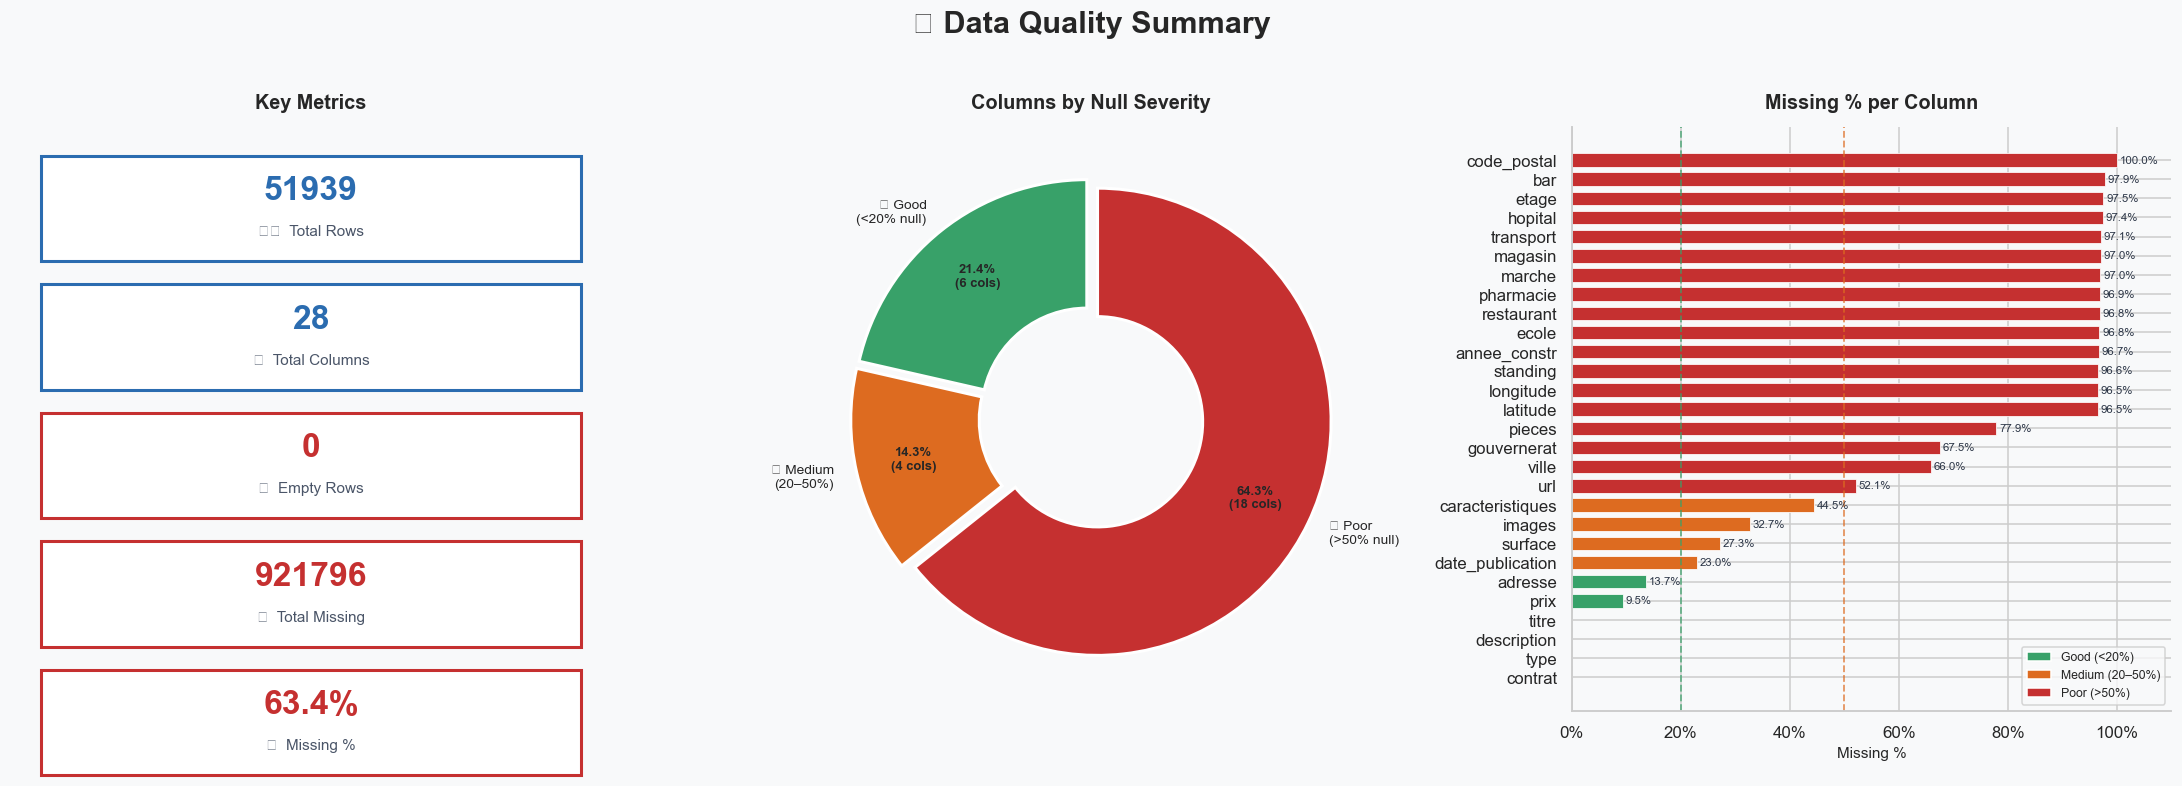

In [365]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=FIG_BG)
fig.suptitle('📋 Data Quality Summary', fontsize=20, fontweight='bold', y=1.02)

# ── 1. KPI Cards ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(FIG_BG)
ax.axis('off')

total_rows    = dataset_full_raw.shape[0]
total_cols    = dataset_full_raw.shape[1]
empty_rows    = dataset_full_raw.isna().all(axis=1).sum()
total_missing = dataset_full_raw.isna().sum().sum()
missing_pct   = total_missing / (total_rows * total_cols) * 100

kpis = [
    ('🗂️  Total Rows',    f'{total_rows}',        '#2B6CB0'),
    ('📊  Total Columns', f'{total_cols}',            '#2B6CB0'),
    ('❌  Empty Rows',    f'{empty_rows}',          '#C53030'),
    ('📉  Total Missing', f'{total_missing}',       '#C53030'),
    ('📈  Missing %',     f'{missing_pct:.1f}%',    '#C53030'),
]

for i, (label, value, color) in enumerate(kpis):
    y = 0.85 - i * 0.22
    ax.add_patch(plt.Rectangle((0.05, y - 0.08), 0.9, 0.18,
                                transform=ax.transAxes, facecolor='white',
                                edgecolor=color, linewidth=2, zorder=2,
                                clip_on=False,
                                **{'radius': 0.02} if False else {}))
    ax.text(0.5, y + 0.04, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold',
            color=color)
    ax.text(0.5, y - 0.03, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='#4A5568')

ax.set_title('Key Metrics', fontweight='bold', fontsize=13, pad=12)

# ── 2. Null Severity Donut ────────────────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(FIG_BG)

severity = {
    '🟢 Good\n(<20% null)':    0,
    '🟡 Medium\n(20–50%)':     0,
    '🔴 Poor\n(>50% null)':    0,
}
good, medium, poor = [], [], []
for c in dataset_full_raw.columns:
    pct = dataset_full_raw[c].isna().mean() * 100
    if pct < 20:
        good.append(c);   severity['🟢 Good\n(<20% null)']   += 1
    elif pct < 50:
        medium.append(c); severity['🟡 Medium\n(20–50%)']    += 1
    else:
        poor.append(c);   severity['🔴 Poor\n(>50% null)']   += 1

sizes  = list(severity.values())
labels = list(severity.keys())
colors = ['#38A169', '#DD6B20', '#C53030']
explode = [0.03] * 3

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*total_cols/100))} cols)',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight('bold')

ax.set_title('Columns by Null Severity', fontweight='bold', fontsize=13, pad=12)

# ── 3. Per-Column Missing % Bar ───────────────────────────────────────────────
ax = axes[2]
ax.set_facecolor(FIG_BG)

miss = (dataset_full_raw.isna().mean() * 100).sort_values(ascending=True)
bar_colors = ['#38A169' if v < 20 else '#DD6B20' if v < 50 else '#C53030' for v in miss]

bars = ax.barh(miss.index, miss.values, color=bar_colors,
               edgecolor='white', linewidth=0.5, height=0.7)

ax.axvline(20, color='#38A169', linestyle='--', linewidth=1.2, alpha=0.7, label='20% threshold')
ax.axvline(50, color='#DD6B20', linestyle='--', linewidth=1.2, alpha=0.7, label='50% threshold')

for bar, val in zip(bars, miss.values):
    if val > 2:
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=7.5, color='#2D3748')

ax.set_xlabel('Missing %', fontsize=10)
ax.set_title('Missing % per Column', fontweight='bold', fontsize=13, pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(0, 110)

# ── Legend patch for bar chart ────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#38A169', label='Good (<20%)'),
                   Patch(facecolor='#DD6B20', label='Medium (20–50%)'),
                   Patch(facecolor='#C53030', label='Poor (>50%)')]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('data_quality_summary.png', dpi=150, bbox_inches='tight',
            facecolor=FIG_BG)
plt.show()

## 3. Missing Value Analysis <a id='3'></a>
- 🔴 **>70% missing** → consider dropping  
- 🟠 **30–70% missing** → impute carefully or use as flag  
- 🟢 **<30% missing** → standard imputation


In [366]:
missing = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().mean()*100).round(1),
}).sort_values('missing_pct', ascending=False)
missing = missing[missing['missing_count'] > 0]

def highlight(val):
    if val > 70:
        return 'background-color: #c0392b; color: white'  # dark red
    elif val > 30:
        return 'background-color: #d35400; color: white'  # dark orange
    else:
        return 'background-color: #27ae60; color: white'  # dark green

missing.style.applymap(highlight, subset=['missing_pct'])

,missing_count,missing_pct
code_postal,51939,100.000000
bar,50827,97.900000
etage,50656,97.500000
hopital,50577,97.400000
transport,50408,97.100000
marche,50366,97.000000
magasin,50380,97.000000
pharmacie,50348,96.900000
ecole,50276,96.800000
restaurant,50294,96.800000


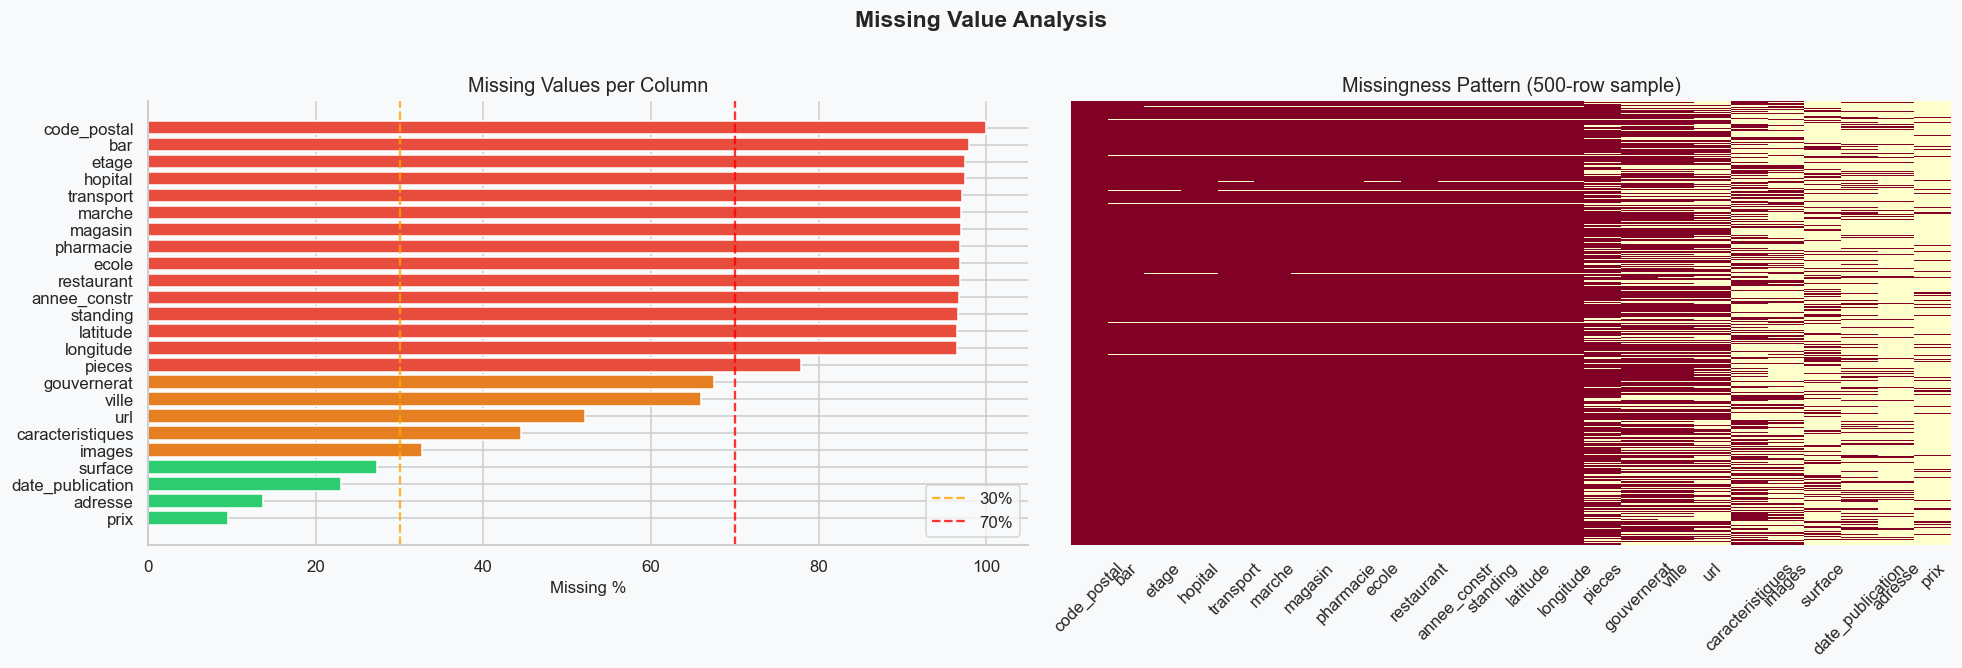

In [367]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left — bar chart
colors = ['#e74c3c' if v > 70 else '#e67e22' if v > 30 else '#2ecc71'
          for v in missing['missing_pct']]
axes[0].barh(missing.index, missing['missing_pct'], color=colors)
axes[0].axvline(30, color='orange', linestyle='--', alpha=0.8, label='30%')
axes[0].axvline(70, color='red',    linestyle='--', alpha=0.8, label='70%')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Missing Values per Column')
axes[0].legend()
axes[0].invert_yaxis()

# Right — heatmap pattern (500-row sample)
sample = df.sample(min(500, len(df)), random_state=42)
sns.heatmap(sample[missing.index].isnull(), cbar=False,
            yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missingness Pattern (500-row sample)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Missing Value Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 4. Numeric Distributions & Outliers <a id='4'></a>
Key numeric features: `prix`, `surface`, `pieces`, `etage`, `annee_constr`

In [368]:
numeric_cols = ['prix', 'surface', 'pieces', 'etage', 'annee_constr']
df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T.style.format('{:.2f}')


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
prix,47025.00,206972.83,2282603.06,0.00,0.00,400.00,1200.00,2000.00,130000.00,960000.00,2500000.00,434400000.00
surface,37781.00,7246.42,530660.68,0.00,1.00,25.00,70.00,130.00,480.00,1650.00,20000.00,80000000.00
pieces,11474.00,3.04,1.30,1.00,1.00,1.00,2.00,3.00,4.00,6.00,6.00,8.00
etage,1283.00,1.71,1.58,-1.00,0.00,0.00,1.00,1.00,2.00,5.00,7.00,9.00
annee_constr,1705.00,2008.55,18.88,1654.00,1950.00,1980.00,2000.00,2012.00,2022.00,2025.00,2026.00,2027.00


In [369]:
# IQR Outlier Detection
print('-'*55)
for col in ['prix', 'surface', 'pieces']:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lo) | (s > hi)).sum()
    print(f'{col:<16} {n_out:>9,} {n_out/len(s)*100:>6.1f}%  [{lo:,.0f} — {hi:,.0f}]')


-------------------------------------------------------
prix                 7,358   15.6%  [-192,000 — 323,200]
surface              2,437    6.5%  [-545 — 1,095]
pieces                   3    0.0%  [-1 — 7]


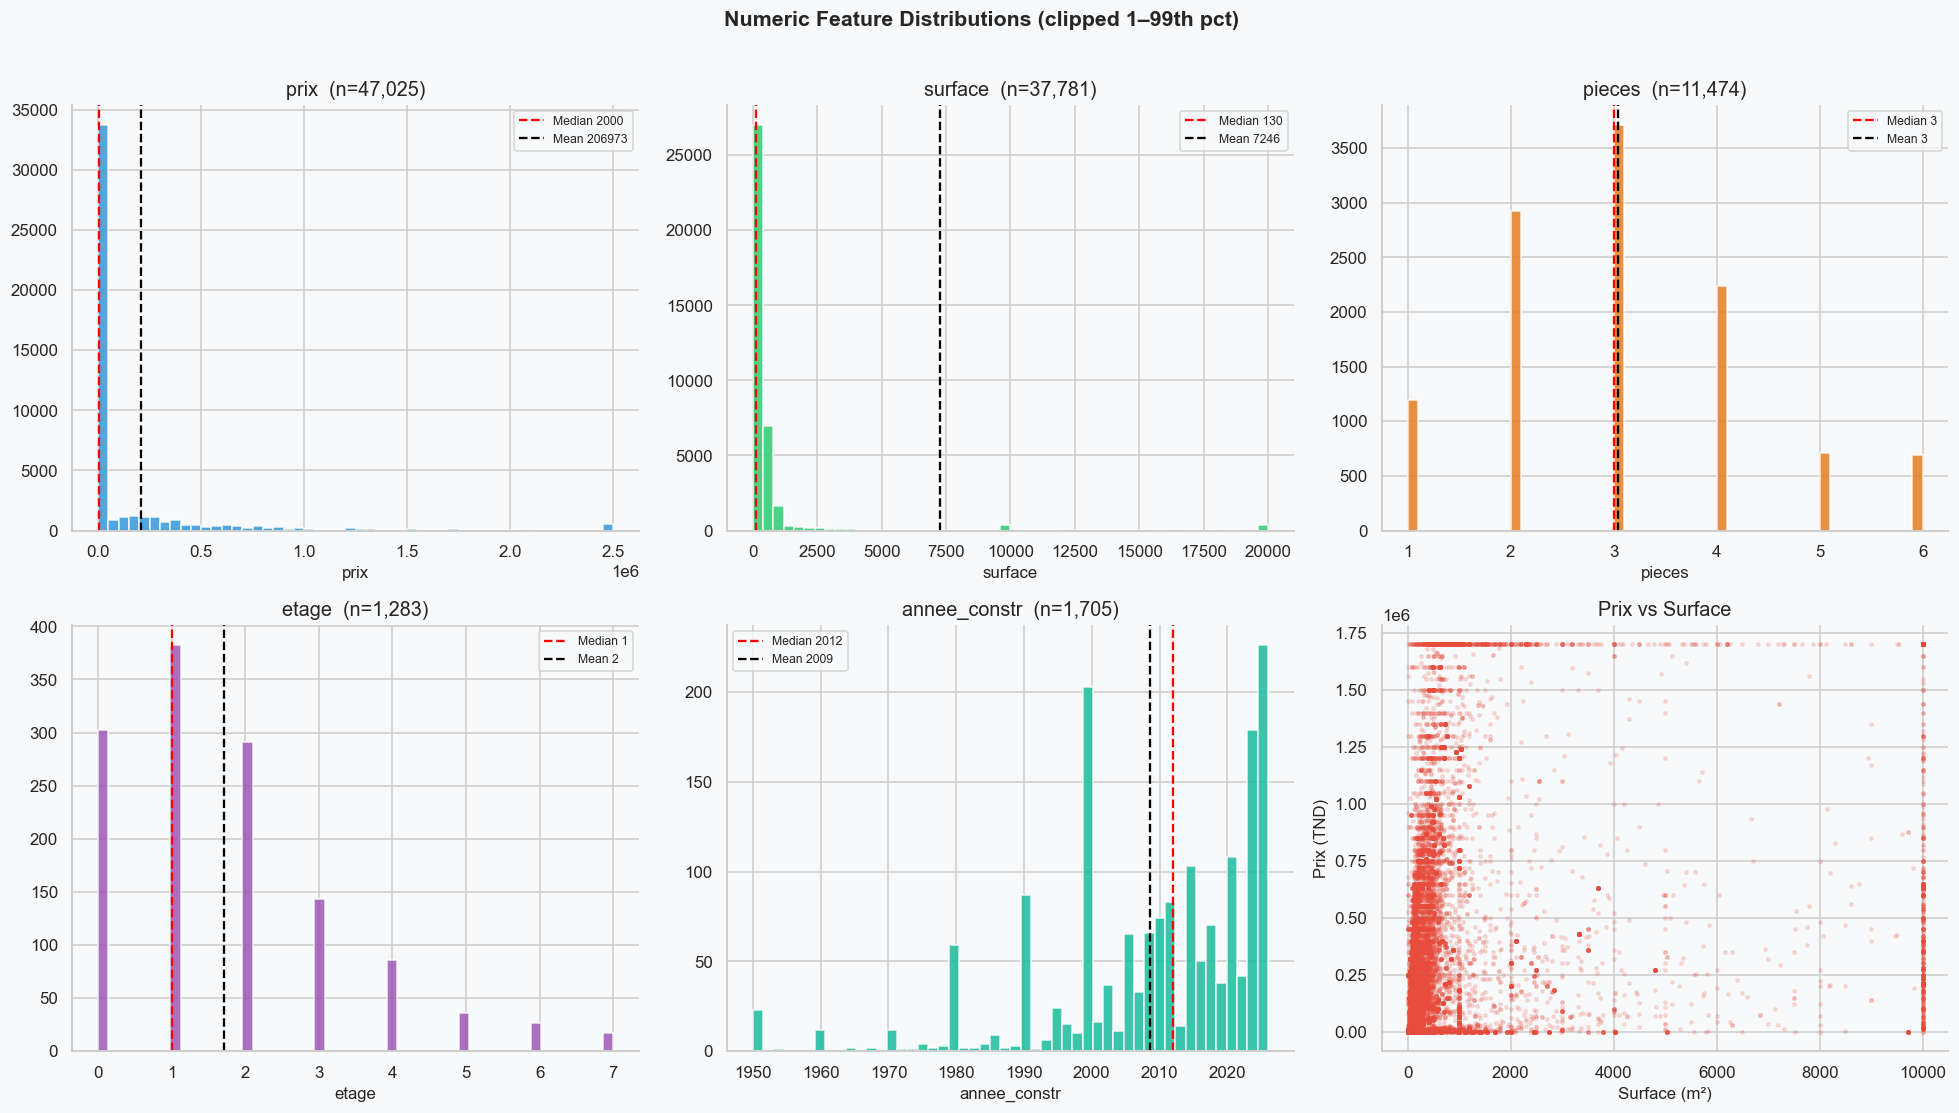

In [370]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = ['prix', 'surface', 'pieces', 'etage', 'annee_constr']
colors     = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#1abc9c']

for ax, col, color in zip(axes.flat, plot_cols, colors):
    data = df[col].dropna()
    clipped = data.clip(data.quantile(0.01), data.quantile(0.99))
    ax.hist(clipped, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red',    ls='--', lw=1.5, label=f'Median {data.median():.0f}')
    ax.axvline(data.mean(),   color='black',  ls='--', lw=1.5, label=f'Mean {data.mean():.0f}')
    ax.set_title(f'{col}  (n={len(data):,})')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

# 6th plot — prix vs surface scatter
ax = axes[1, 2]
mask = df['prix'].notna() & df['surface'].notna()
ax.scatter(
    df.loc[mask, 'surface'].clip(0, df['surface'].quantile(0.98)),
    df.loc[mask, 'prix'].clip(0, df['prix'].quantile(0.98)),
    alpha=0.15, s=5, color='#e74c3c'
)
ax.set_xlabel('Surface (m²)')
ax.set_ylabel('Prix (TND)')
ax.set_title('Prix vs Surface')

plt.suptitle('Numeric Feature Distributions (clipped 1–99th pct)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Categorical Analysis <a id='5'></a>
Key categorical features: `contrat`, `type`, `gouvernerat`, `standing`

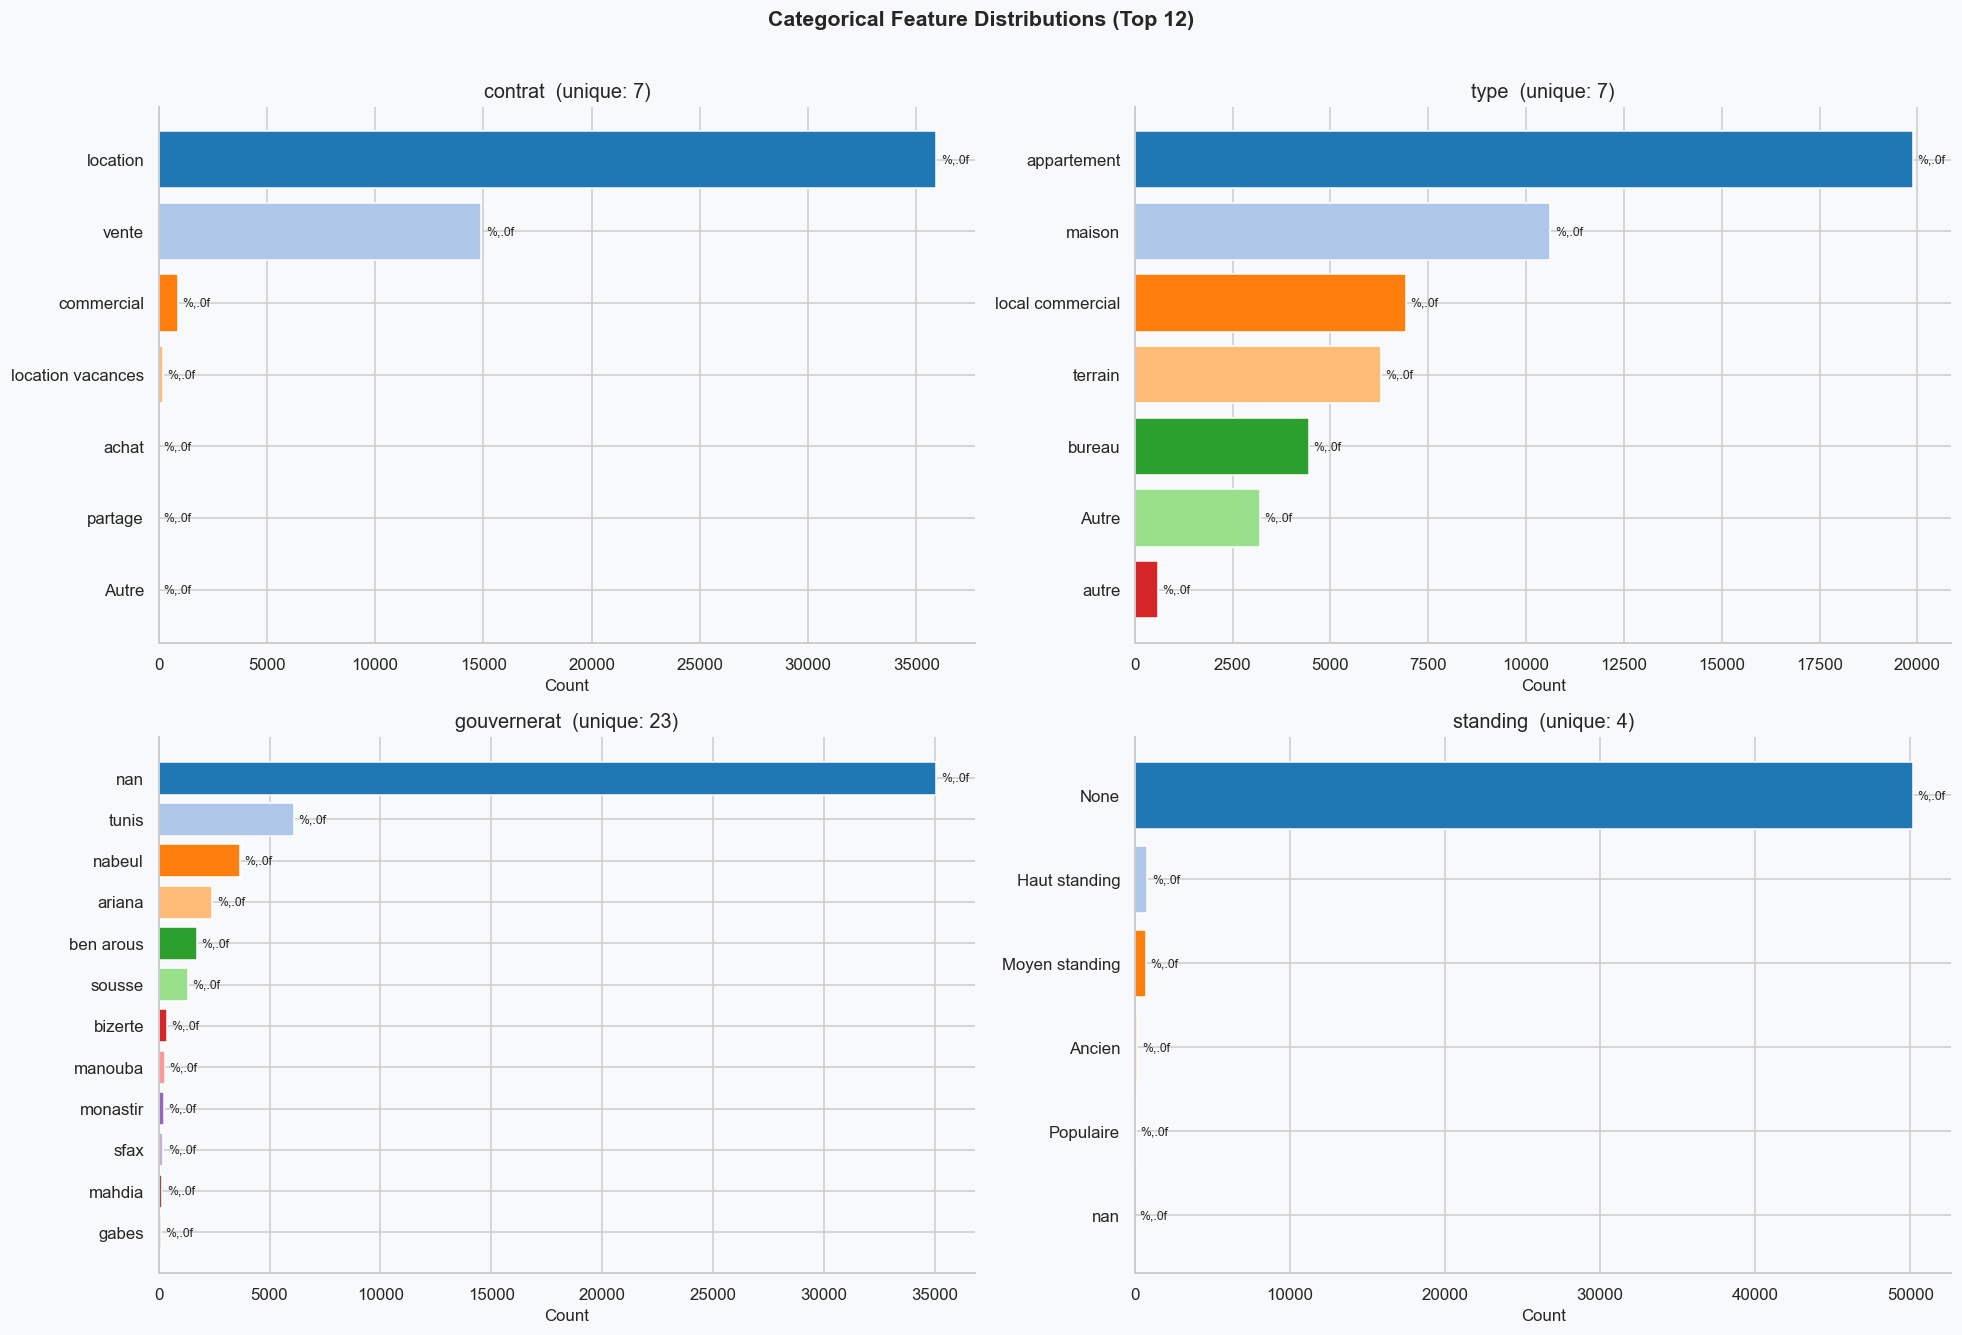

In [371]:
cat_cols = ['contrat', 'type', 'gouvernerat', 'standing']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col in zip(axes.flat, cat_cols):
    vc = df[col].value_counts(dropna=False).head(12)
    bars = ax.barh(vc.index.astype(str), vc.values,
                   color=plt.cm.tab20.colors[:len(vc)])
    ax.bar_label(bars, fmt='%,.0f', padding=3, fontsize=8)
    ax.set_title(f'{col}  (unique: {df[col].nunique()})')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.suptitle('Categorical Feature Distributions (Top 12)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


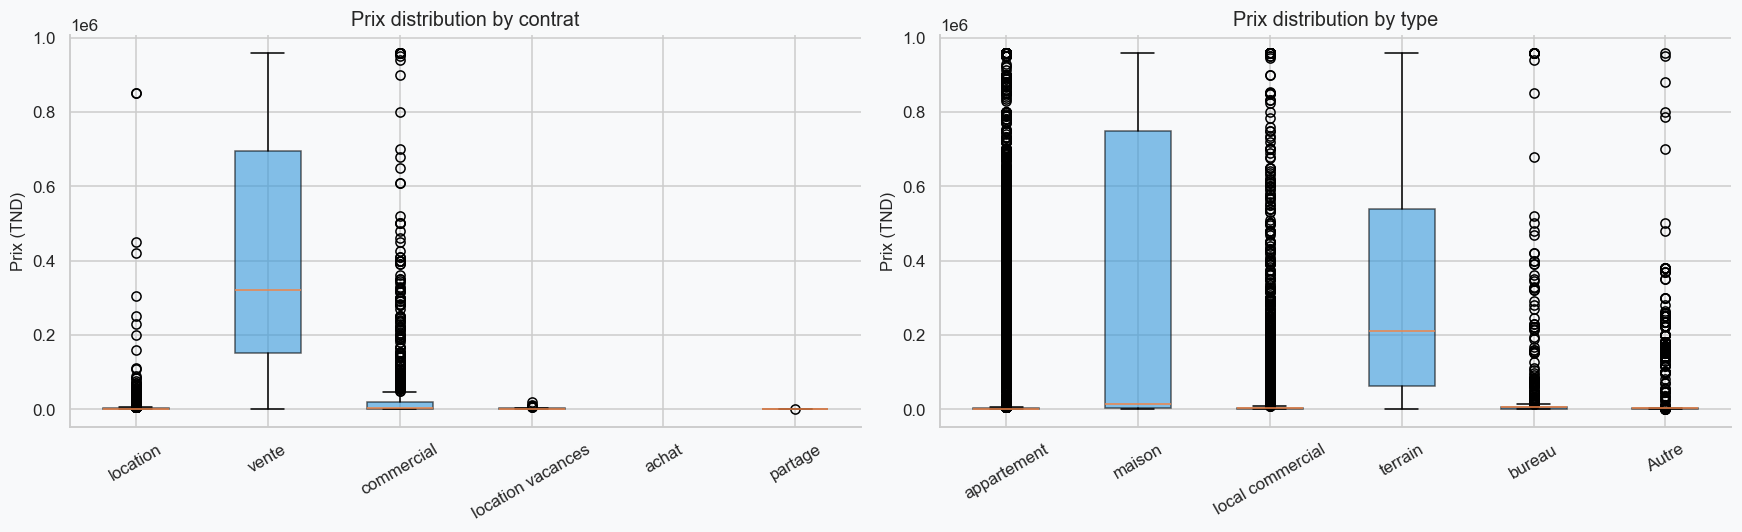

In [372]:
# Price distribution by contrat type
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['contrat', 'type']):
    top_cats = df[col].value_counts().head(6).index
    data = [df.loc[df[col]==cat, 'prix'].dropna().clip(0, df['prix'].quantile(0.95))
            for cat in top_cats]
    ax.boxplot(data, labels=top_cats, patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
    ax.set_title(f'Prix distribution by {col}')
    ax.set_ylabel('Prix (TND)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


## 6. Temporal Analysis <a id='6'></a>

Date range   : 2015-03-04 → 2026-02-21
Coverage     : 40,010 / 51,939 rows (77.0%)


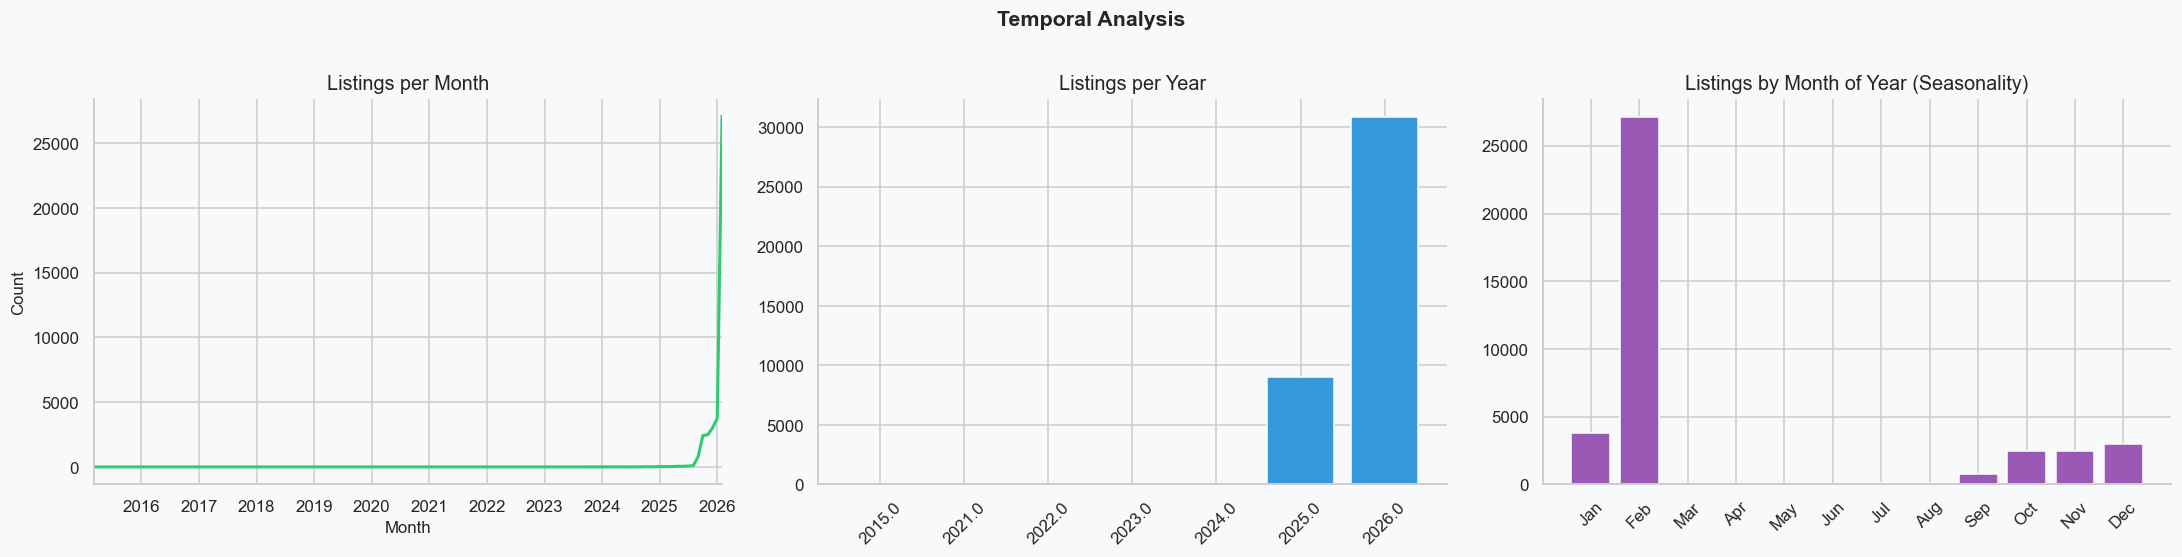

In [373]:
df['date_publication'] = pd.to_datetime(df['date_publication'], errors='coerce')

print(f"Date range   : {df['date_publication'].min().date()} → {df['date_publication'].max().date()}")
print(f"Coverage     : {df['date_publication'].notna().sum():,} / {len(df):,} rows "
      f"({df['date_publication'].notna().mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Monthly trend
monthly = df.groupby(df['date_publication'].dt.to_period('M')).size()
monthly.plot(ax=axes[0], color='#2ecc71', linewidth=2)
axes[0].fill_between(range(len(monthly)), monthly.values, alpha=0.2, color='#2ecc71')
axes[0].set_title('Listings per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')

# By year
yr = df['date_publication'].dt.year.value_counts().sort_index()
axes[1].bar(yr.index.astype(str), yr.values, color='#3498db', edgecolor='white')
axes[1].set_title('Listings per Year')
axes[1].tick_params(axis='x', rotation=45)

# By month of year
mon = df['date_publication'].dt.month.dropna().astype(int).value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar([month_names[m-1] for m in mon.index], mon.values, color='#9b59b6', edgecolor='white')
axes[2].set_title('Listings by Month of Year (Seasonality)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Temporal Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 7. Geographic Analysis <a id='7'></a>

Listings with GPS : 1,795 (3.5%)


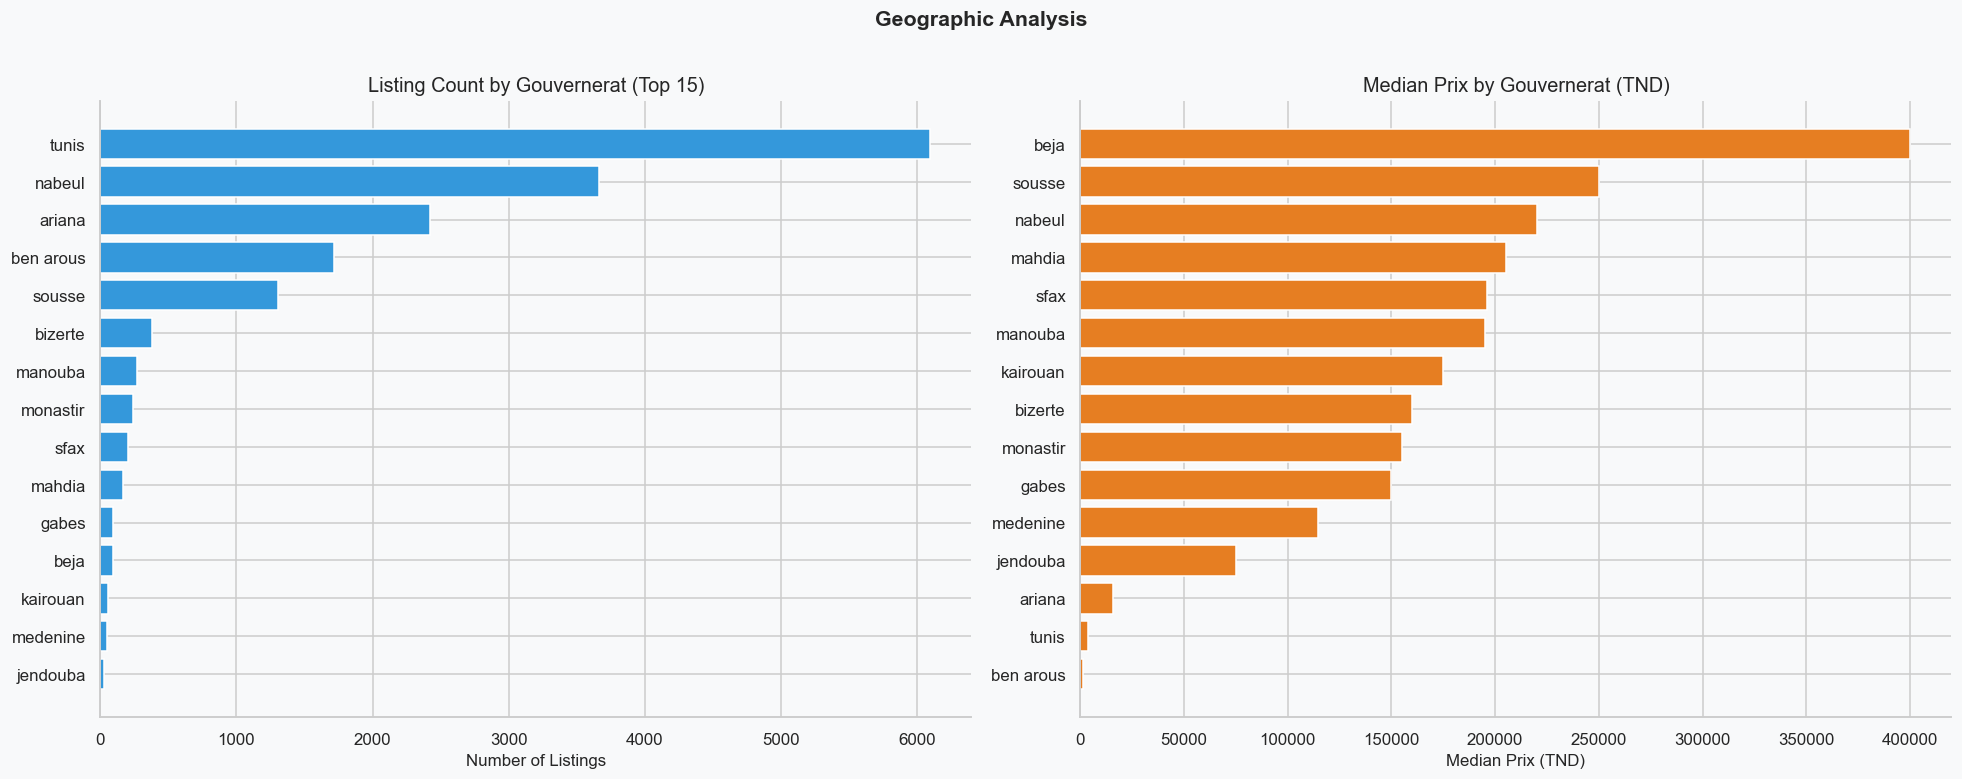

In [374]:
print(f"Listings with GPS : {df['latitude'].notna().sum():,} ({df['latitude'].notna().mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_govs = df['gouvernerat'].value_counts().head(15).index

# Count by gouvernerat
cnt = df['gouvernerat'].value_counts().head(15)
axes[0].barh(cnt.index, cnt.values, color='#3498db')
axes[0].set_title('Listing Count by Gouvernerat (Top 15)')
axes[0].set_xlabel('Number of Listings')
axes[0].invert_yaxis()

# Median price by gouvernerat
med_price = (df[df['gouvernerat'].isin(top_govs)]
             .groupby('gouvernerat')['prix']
             .median()
             .sort_values(ascending=False))
axes[1].barh(med_price.index, med_price.values, color='#e67e22')
axes[1].set_title('Median Prix by Gouvernerat (TND)')
axes[1].set_xlabel('Median Prix (TND)')
axes[1].invert_yaxis()

plt.suptitle('Geographic Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


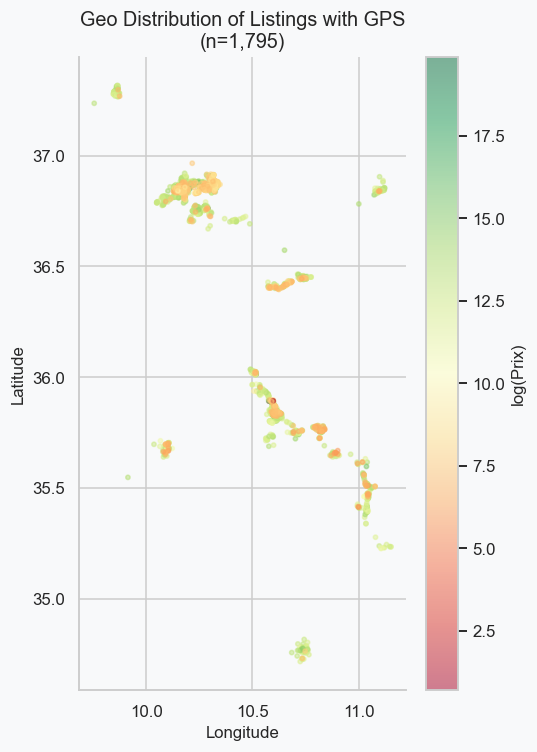

In [375]:
# GPS scatter plot
gps = df.dropna(subset=['latitude','longitude'])
# Filter to Tunisia bounding box
gps = gps[(gps['latitude'].between(30, 38)) & (gps['longitude'].between(7, 12))]

fig, ax = plt.subplots(figsize=(5, 7))
scatter = ax.scatter(gps['longitude'], gps['latitude'],
                     c=np.log1p(gps['prix']), cmap='RdYlGn',
                     s=8, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='log(Prix)')
ax.set_title(f'Geo Distribution of Listings with GPS\n(n={len(gps):,})')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()


## 8. Correlation Analysis <a id='8'></a>

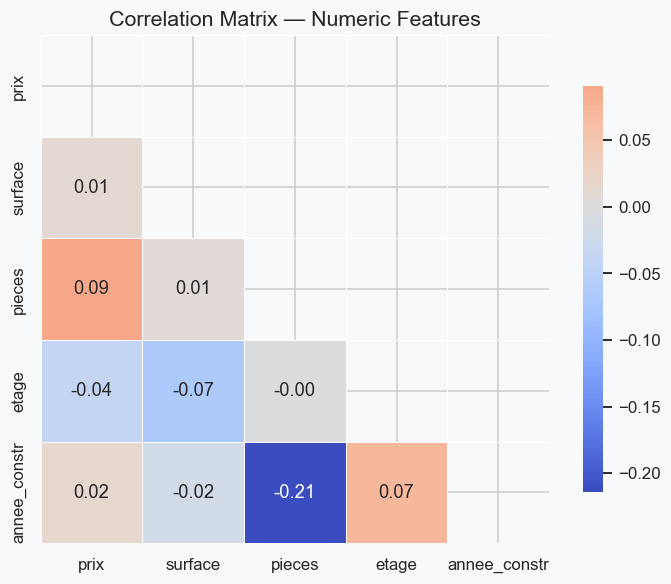

In [376]:


# Columns to correlate
corr_cols = ['prix', 'surface', 'pieces', 'etage', 'annee_constr']
corr = df[corr_cols].corr()

# Figure
plt.figure(figsize=(8, 6))

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Heatmap
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix — Numeric Features', fontsize=14)
plt.show()

## 10. Data Quality Issues Summary <a id='10'></a>
Systematic review of all quality problems found above.

In [377]:
issues = []

# Price
n = (df['prix'] <= 0).sum()
if n: issues.append(('prix ≤ 0',             n, 'Remove — impossible price'))
n = (df['prix'] > 50_000_000).sum()
if n: issues.append(('prix > 50M TND',        n, 'Remove — likely data entry error'))
issues.append(('prix missing',               df['prix'].isna().sum(), 'Impute or flag'))

# Surface
n = (df['surface'] <= 0).sum()
if n: issues.append(('surface ≤ 0',           n, 'Remove — impossible surface'))
n = (df['surface'] > 10_000).sum()
if n: issues.append(('surface > 10,000 m²',   n, 'Review — unusually large'))
issues.append(('surface missing',            df['surface'].isna().sum(), 'Impute or flag'))

# Construction year
n = (df['annee_constr'] < 1800).sum()
if n: issues.append(('annee_constr < 1800',   n, 'Set to NaN — impossible year'))
n = (df['annee_constr'] > datetime.now().year + 5).sum()
if n: issues.append(('annee_constr > now+5',  n, 'Set to NaN — future year'))

# Structural
issues.append(('code_postal 100% empty', len(df), 'DROP column entirely'))

# GPS
issues.append(('latitude/longitude sparse', df['latitude'].isna().sum(),
               f'Only {df["latitude"].notna().mean()*100:.1f}% have GPS — enrich via geocoding'))

issues_df = pd.DataFrame(issues, columns=['Issue', 'Count', 'Action'])
issues_df['Count'] = issues_df['Count'].apply(lambda x: f'{x:,}')
issues_df.style.set_properties(**{'text-align': 'left'})
issues_df


,Issue,Count,Action
0,prix ≤ 0,650,Remove — impossible price
1,prix > 50M TND,2,Remove — likely data entry error
2,prix missing,"4,914",Impute or flag
3,surface ≤ 0,9,Remove — impossible surface
4,"surface > 10,000 m²",494,Review — unusually large
5,surface missing,"14,158",Impute or flag
6,annee_constr < 1800,1,Set to NaN — impossible year
7,code_postal 100% empty,"51,939",DROP column entirely
8,latitude/longitude sparse,"50,144",Only 3.5% have GPS — enrich via geocoding


## 11. Data Preparation <a id='11'></a>
Applying all fixes identified above, plus feature engineering.

### 11.1  remove duplicates

In [378]:
df_clean = dataset_full_raw.copy()

# Remove full duplicate rows
before = len(df_clean)
df_clean.reset_index(drop=True, inplace=True)
print(f'Exact duplicates removed : {before - len(df_clean):,}')

# Remove duplicate URLs (keep first occurrence)
if 'url' in df_clean.columns:
    before = len(df_clean)
    df_clean = df_clean[~df_clean['url'].duplicated(keep='first') | df_clean['url'].isna()]
    df_clean.reset_index(drop=True, inplace=True)
    print(f'Duplicate URLs removed   : {before - len(df_clean):,}')

print(f'\nShape after dedup: {df_clean.shape}')


Exact duplicates removed : 0
Duplicate URLs removed   : 0

Shape after dedup: (51939, 28)


### 11.2 Remove impossible / erroneous numeric values

In [379]:
before = len(df_clean)

# Prix
df_clean = df_clean[~(df_clean['prix'].notna() & (df_clean['prix'] <= 0))]
df_clean = df_clean[~(df_clean['prix'].notna() & (df_clean['prix'] > 5_000_000))]

# Surface
df_clean = df_clean[~(df_clean['surface'].notna() & (df_clean['surface'] <= 0))]
df_clean = df_clean[~(df_clean['surface'].notna() & (df_clean['surface'] > 10_000))]

# Construction year — nullify out-of-range instead of dropping rows
df_clean.loc[df_clean['annee_constr'] < 1800, 'annee_constr'] = np.nan
df_clean.loc[df_clean['annee_constr'] > datetime.now().year + 5, 'annee_constr'] = np.nan

df_clean.reset_index(drop=True, inplace=True)
print(f'Rows removed for bad numeric values: {before - len(df_clean):,}')
print(f'Shape: {df_clean.shape}')


Rows removed for bad numeric values: 1,270
Shape: (50669, 28)


### 11.3 Standardize categorical text

In [380]:
df_clean['contrat'] = df_clean['contrat'].str.strip().str.lower()
df_clean['type']    = df_clean['type'].str.strip().str.lower()
df_clean['gouvernerat'] = df_clean['gouvernerat'].str.strip().str.title()

# Normalize contrat variants
contrat_map = {
    'a vendre': 'vente', 'à vendre': 'vente',
    'a louer' : 'location', 'à louer': 'location',
    'location saisonnière': 'location_saisonniere',
}
df_clean['contrat'] = df_clean['contrat'].replace(contrat_map)

print('contrat value counts:')
print(df_clean['contrat'].value_counts().to_string())


contrat value counts:
contrat
location             35898
vente                13670
commercial             866
location vacances      206
achat                   15
partage                 12
autre                    2


### 11.4 Feature Engineering

In [381]:
# Prix per m²
mask = df_clean['prix'].notna() & df_clean['surface'].notna() & (df_clean['surface'] > 0)
df_clean['prix_m2'] = np.nan
df_clean.loc[mask, 'prix_m2'] = (df_clean.loc[mask, 'prix'] / df_clean.loc[mask, 'surface']).round(0)
df_clean.loc[df_clean['prix_m2'] > 5000, 'prix_m2'] = np.nan  # cap extreme
df_clean.loc[df_clean['prix_m2'] < 10,     'prix_m2'] = np.nan

# Log transforms (for modeling — reduces skew)
df_clean['log_prix']    = np.log1p(df_clean['prix'])
df_clean['log_surface'] = np.log1p(df_clean['surface'])

# Date features
df_clean['date_publication'] = pd.to_datetime(df_clean['date_publication'], errors='coerce')
df_clean['pub_year']    = df_clean['date_publication'].dt.year.astype('Int64')
df_clean['pub_month']   = df_clean['date_publication'].dt.month.astype('Int64')
df_clean['pub_quarter'] = df_clean['date_publication'].dt.quarter.astype('Int64')

print('New columns created:')
new_cols = ['prix_m2', 'log_prix', 'log_surface', 'pub_year', 'pub_month', 'pub_quarter']
print(df_clean[new_cols].describe().round(2).T.to_string())


New columns created:
               count    mean     std     min     25%     50%     75%     max
prix_m2     28774.00  699.19 1111.42   10.00   15.00   53.00 1135.00 5000.00
log_prix    45757.00    8.97    2.60    0.69    7.09    7.65   11.70   15.42
log_surface 36571.00    5.10    1.27    0.69    4.26    4.81    6.11    9.21
pub_year    39433.00 2025.77    0.43 2015.00 2026.00 2026.00 2026.00 2026.00
pub_month   39433.00    3.85    3.74    1.00    2.00    2.00    2.00   12.00
pub_quarter 39433.00    1.64    1.20    1.00    1.00    1.00    1.00    4.00


### 11.5 Recover missing `pieces` from text

In [382]:
def extract_pieces(text):
    if pd.isna(text): return np.nan
    m = re.search(r'(\d+)\s*pi[eè]ces?', str(text).lower())
    if m: return float(m.group(1))
    m = re.search(r'(\d+)\s*ch(ambres?)?', str(text).lower())
    if m: return float(m.group(1))
    return np.nan

missing_pieces_mask = df_clean['pieces'].isna()
recovered = (
    df_clean.loc[missing_pieces_mask, 'description'].apply(extract_pieces)
    .combine_first(
    df_clean.loc[missing_pieces_mask, 'titre'].apply(extract_pieces))
)
df_clean.loc[missing_pieces_mask, 'pieces'] = recovered

n_recovered = (df_clean['pieces'].notna() & missing_pieces_mask).sum()
print(f'Pieces recovered from text: {n_recovered:,} rows')
print(f'Pieces coverage: {df_clean["pieces"].notna().mean()*100:.1f}%')


Pieces recovered from text: 3,249 rows
Pieces coverage: 28.8%


### 11.6 Binary proximity & amenity flags

In [383]:
# Proximity columns → binary flags
proximity_cols = ['ecole','pharmacie','hopital','marche','magasin',
                  'bar','restaurant','transport']
for col in proximity_cols:
    if col in df_clean.columns:
        df_clean[f'prox_{col}'] = df_clean[col].notna().astype('int8')

# Amenity flags from caracteristiques
amenity_flags = ['piscine','parking','garage','jardin','terrasse',
                 'ascenseur','climatisation','balcon','gardien']
for amen in amenity_flags:
    df_clean[f'has_{amen}'] = df_clean['caracteristiques'].str.lower().str.contains(amen, na=False).astype('int8')

print('Proximity flags created:', [f'prox_{c}' for c in proximity_cols])
print('Amenity flags created  :', [f'has_{c}' for c in amenity_flags])


Proximity flags created: ['prox_ecole', 'prox_pharmacie', 'prox_hopital', 'prox_marche', 'prox_magasin', 'prox_bar', 'prox_restaurant', 'prox_transport']
Amenity flags created  : ['has_piscine', 'has_parking', 'has_garage', 'has_jardin', 'has_terrasse', 'has_ascenseur', 'has_climatisation', 'has_balcon', 'has_gardien']


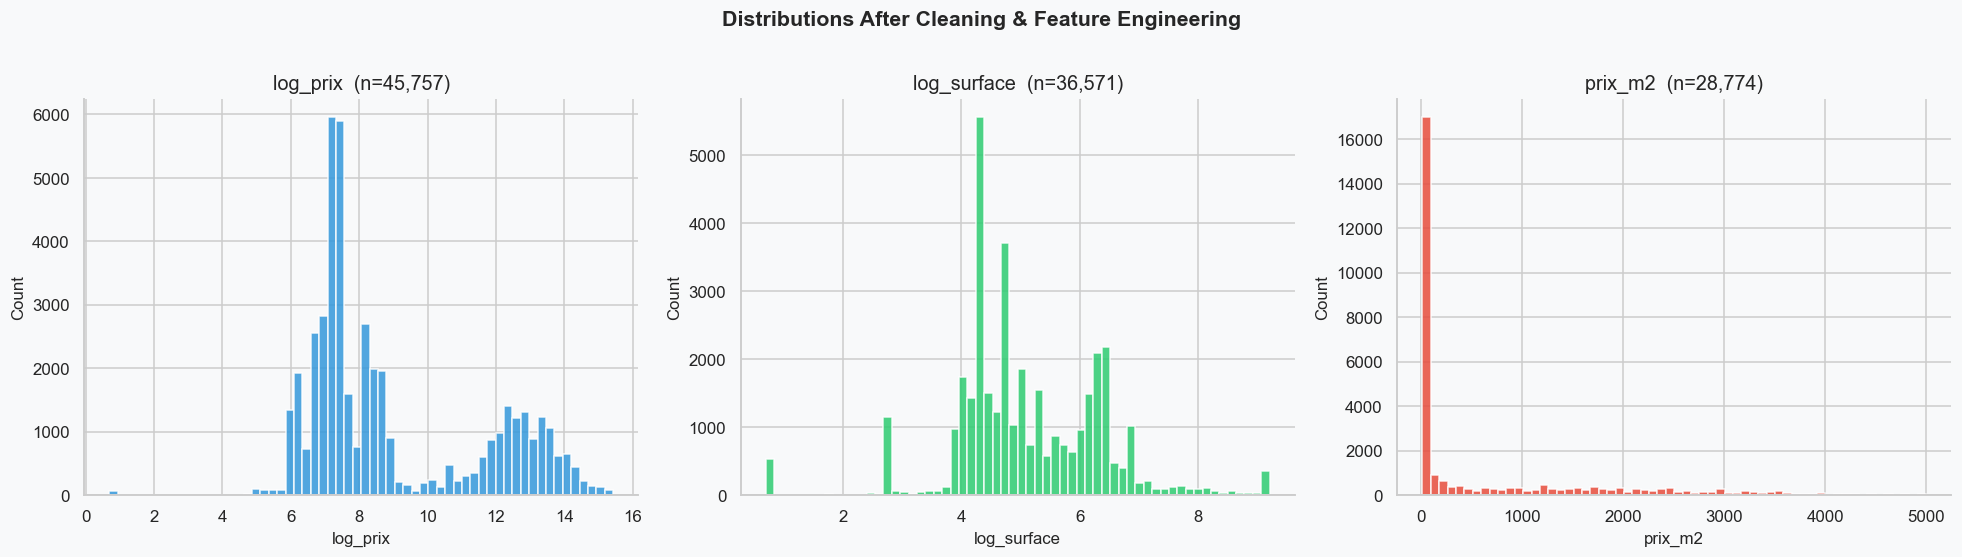

In [384]:
# Clean distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes,
    ['log_prix', 'log_surface', 'prix_m2'],
    ['#3498db', '#2ecc71', '#e74c3c']):
    data = df_clean[col].dropna()
    ax.hist(data, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}  (n={len(data):,})')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distributions After Cleaning & Feature Engineering',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [385]:
# Export
df_clean.to_csv('dataset_clean.csv', index=False)
print('✔  Exported → dataset_clean.csv')
print(f'   Shape: {df_clean.shape}')
print()
print('The clean DataFrame is available as df_clean')
df_clean.dtypes.to_frame('dtype')


✔  Exported → dataset_clean.csv
   Shape: (50669, 51)

The clean DataFrame is available as df_clean


,dtype
url,object
contrat,object
type,object
prix,float64
titre,string[python]
description,string[python]
surface,float64
pieces,Float64
etage,Int64
code_postal,object


# Stage 2

extraction des caracteristique par nlp 